# pyFCS Tutorial

pyFCS covers the following FCS methods:

1. Basic auto and cross correlation as in [Lawrence et. al. 2006](https://doi.org/10.1364/OL.31.000829)
2. Weighted auto and cross correlation for Fluorescence lifetime Correlation Spectroscopy as in [Bohmer et. al. 2002](https://doi.org/10.1016/S0009-2614(02)00044-1), reviewed in [Kapusta et. al. 2012](https://doi.org/10.3390/ijms131012890) and [Ghosh et.al. 2018](https://doi.org/10.1016/j.ymeth.2018.02.009).
3. Purified FCS according to [Lawrence et. al. 2007](https://doi.org/10.1529/biophysj.106.093591)

Finally it should be noted that methods 2 and 3 were independent extentions of method 1, and these two methods
are also capable of being combined, and indeed pyFCS is capable of supporting this combination.

## Load data with FRETBursts

First we need to import the modules we'll use in this tutorial

> **Note**
>
> scipy is imported for performing optimizations/fittings of fluorescence decays.
> One could (and often does) use the raw decays instead, meaning scipy would not
> be necessary.
> However, this notebook does not peform fittings of the correlation functions.
> This process will also use scipy

In [1]:
import os
import numpy as np # standard python mathematics module
from scipy import optimize, stats 
import matplotlib.pyplot as plt # standard scientific plotting module

import fretbursts as frb # for pre-processing data
import pyFCS as fcs # for performing correlation calculations

 - Optimized (cython) burst search loaded.
--------------------------------------------------------------
 You are running FRETBursts (version 0.7.post178+g28e0e4d42).

 If you use this software please cite the following paper:

   FRETBursts: An Open Source Toolkit for Analysis of Freely-Diffusing Single-Molecule FRET
   Ingargiola et al. (2016). http://dx.doi.org/10.1371/journal.pone.0160716 

--------------------------------------------------------------


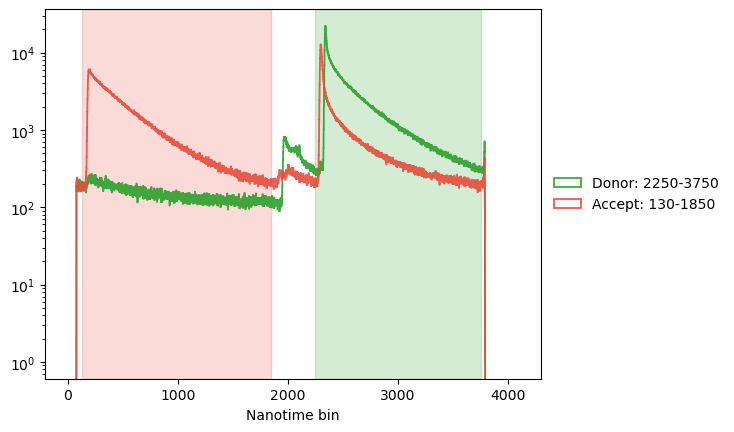

In [2]:
directory = '/home/paul/Python/mpH2MMrevision/'
filename = 'HP3_TE50_SPC630.hdf5'
# Check that file exists
assert os.path.isfile(directory+filename), "File not found"
filename = directory+filename

# load data
data_all = frb.loader.photon_hdf5(filename)
# fix order of photons
for i in range(data_all.nch):
    sort = np.argsort(data_all.ph_times_t[i])
    data_all.ph_times_t[i], data_all.det_t[i], data_all.nanotimes_t[i] = data_all.ph_times_t[i][sort], data_all.det_t[i][sort], data_all.nanotimes_t[i][sort]

# plot alternation histogram to verify correct excitation windows
frb.bpl.plot_alternation_hist(data_all)

**Apply excitation period** adjust periods if necessary

# Total photons (after ALEX selection):     6,470,880
#  D  photons in D+A excitation periods:    3,220,872
#  A  photons in D+A excitation periods:    3,250,008
# D+A photons in  D  excitation period:     4,109,822
# D+A photons in  A  excitation period:     2,361,058



<Axes: title={'center': 'mpH2MMrevision_HP3_TE50_SPC630'}, xlabel='Time (s)', ylabel='# ph'>

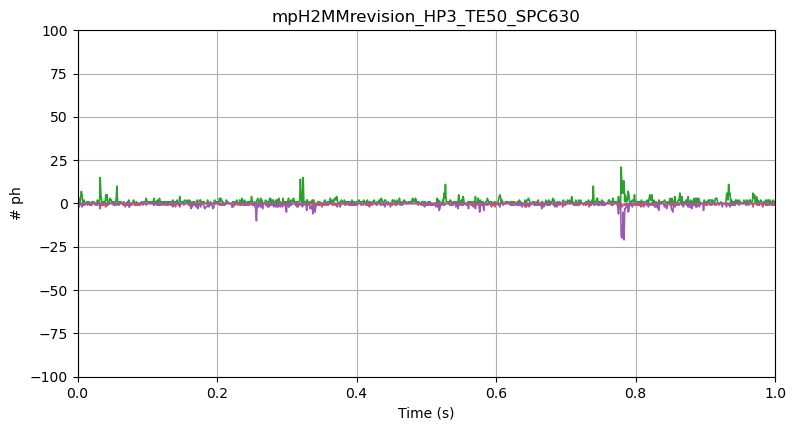

In [3]:
# data_raw.D_ON = data_raw.D_ON # replace with [begin D_ex, end D_ex] period if period not correctly identified in HDF5 file
# data_raw.A_ON = data_raw.A_ON # replace with [begin A_ex, end A_ex] period if period not correctly identified in HDF5 file
frb.loader.alex_apply_period(data_all)
frb.dplot(data_all, frb.timetrace)

# 1. Basic correlation

The primary function of pyFCS is `correlate()`, which is capable of performing the calculation of correlation from beginnign to end.

The most basic signature is as follows:

```python
correlation = fcs.correlate(timesT, timesU, bins)
```

where `timesT` and `timesU` are arrays of photon arrival macrotimes, and `bins` is an array defining the bin edges.
`bins` is always a 1D integer array. For now `timesT` and `timesU` are also 1D integer arrays.
Internally they are converted to `np.uint64` arrays, so it is most efficient if the inputs are `np.uint64`.
For autocorrelation `timesT` and `timesU` shoudl be the same array, while cross-correlations they will be different.

> **NOTE**
>
> `timesT` and `timesU` become sequences of 1D integer arrays in burst/purified FCS, this will be adressed in section 2

By default `correlate()` performs all of the normalizations, but setting one or both of the `normalize` or/and `norm_bin_width` keyword arguments to `False` will not apply the relevant normalization factor.

So let's see an example:

**First we extract the times of each stream separetely, and make an array defining the bin edges**

In [4]:
# Get the photon times for the desired photon streams
timesD = data_all.get_ph_times(ph_sel=frb.Ph_sel(Dex='DAem'))
timesDD = data_all.get_ph_times(ph_sel=frb.Ph_sel(Dex='Dem'))
timesDA = data_all.get_ph_times(ph_sel=frb.Ph_sel(Dex='Aem'))
timesAA = data_all.get_ph_times(ph_sel=frb.Ph_sel(Aex='Aem'))

# generate bins
tbins = np.logspace(-6.5, -1, 25) # generage log spaced bins
bins = (tbins/data_all.clk_p).astype(np.uint64) # convert to timestamps unit by dividing by clk_p and convert to np.uint64 type

**Now we calculate the autocorrelation functions**

In [5]:
autocorrlD = fcs.correlate(timesD, timesD, bins)
autocorrlDD = fcs.correlate(timesDD, timesDD, bins)
autocorrlDA = fcs.correlate(timesDA, timesDA, bins)
autocorrlAA = fcs.correlate(timesAA, timesAA, bins)

crosscorrlDDAA = fcs.correlate(timesDD, timesAA, bins)
crosscorrlDDDA = fcs.correlate(timesDD, timesDA, bins)

**And finally display the correlations**

Text(0, 0.5, 'G')

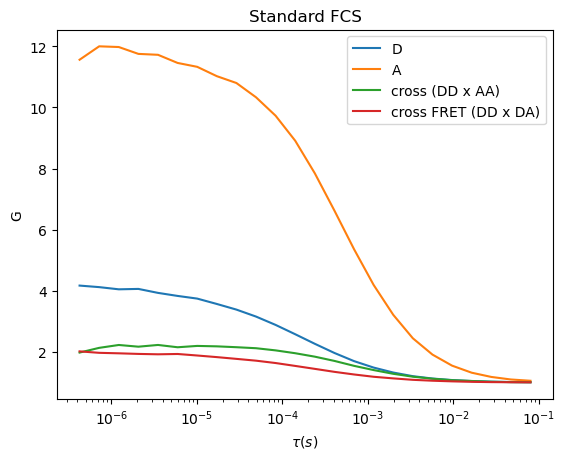

In [6]:
tdbins = tbins[:-1] + np.diff(tbins)/2
plt.semilogx(tdbins, autocorrlD, label='D')
plt.semilogx(tdbins, autocorrlAA, label='A')
plt.semilogx(tdbins, crosscorrlDDAA, label='cross (DD x AA)')
plt.semilogx(tdbins, crosscorrlDDDA, label='cross FRET (DD x DA)')
plt.legend()
plt.title("Standard FCS")
plt.xlabel(r"$\tau (s)$")
plt.ylabel("G")

# 2. Lifetime FCS

Fluorescence lifetime Correlation Spectroscopy uses knowledge of the lifetime of different species to build distinct correlations for several species.

This is done using weighting functions for nanotimes. So before FLCS can be performed, it is necessary to get the decays of each species, and then to compute the weigths arrays, which form an ortho-normal basis set. This calculation is presented in [Ghosh et. al. 2018](https://doi.org/10.1016/j.ymeth.2018.02.009) Section 2, and particularly eq. 5 for a deeper explanation of how this is done.

## 2.1 Burst selection for generating decays

How each decay is determined is up to the user, it would be ideal for this to be determined from a "pure" sample, but that is not always possible.

In this example, instead, the decays will be determined from the decays of bursts that are on the edges of their respective subpopulations, away from the the dynamics.

> **NOTE**
>
> While in this example we are only using the data from this data set, it is common to build decays from other measurements of appropriate species.
> In fact, this is usually the better strategy because it means more data goes into the decay, reducing noise and errors.

### 2.1.1 Caclulate background

 - Calculating BG rates ... get bg th arrays
Channel 0
[DONE]


<Axes: title={'center': 'mpH2MMrevision_HP3_TE50_SPC630'}, xlabel='Inter-photon delays (ms)', ylabel='# Delays'>

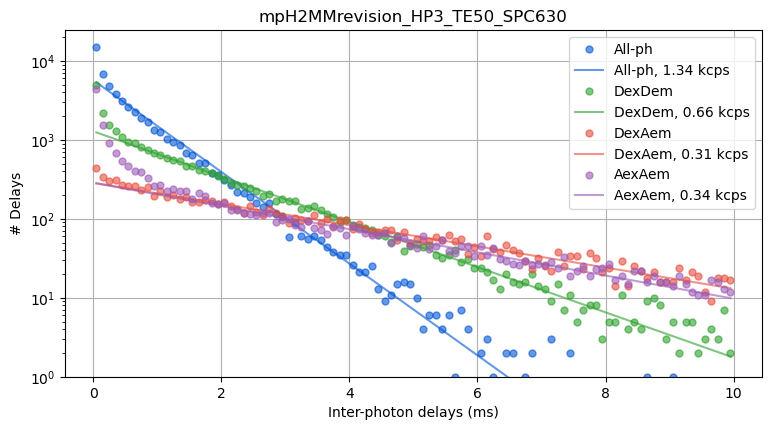

In [7]:
data_all.calc_bg(frb.bg.exp_fit, F_bg=1.7, time_s=30)
frb.dplot(data_all, frb.hist_bg)

<Axes: title={'center': 'mpH2MMrevision_HP3_TE50_SPC630'}, xlabel='Time (s)', ylabel='BG rate (kcps)'>

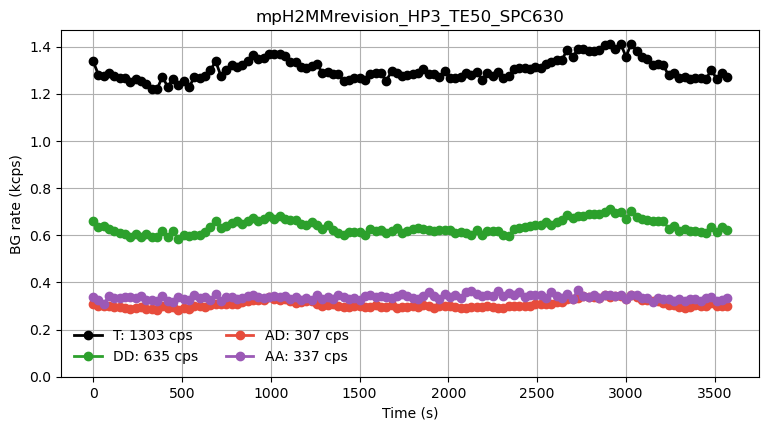

In [8]:
frb.dplot(data_all, frb.timetrace_bg)

### Burst search and selection

Remember the purpose of this bursts selection is to determine the decays of each "pure" species.
Therefore the search/selection should be relatively stringent for overall burst size,
**but** it should **not** remove any donor-only, acceptor-only etc. species, as photons from such molecules will be present in the raw data.
Instead, each species should make it's own decay.

In [9]:
data_all.burst_search(m=10, F=6)
data_all = data_all.select_bursts(frb.select_bursts.size, th1=30, add_naa=True)

 - Performing burst search (verbose=False) ...[DONE]
 - Calculating burst periods ...[DONE]
 - Counting D and A ph and calculating FRET ... 
   - Applying background correction.
   [DONE Counting D/A]


<class 'matplotlib.figure.Figure'>


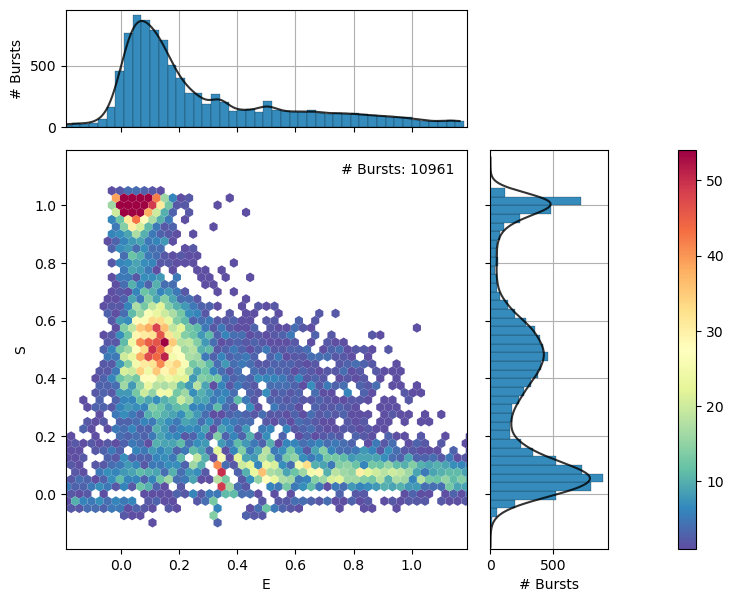

In [10]:
frb.alex_jointplot(data_all);

### 2.1.2 Select "pure" species

Now that an "all-burst" selection has been performed, we need to isolate each "pure" species that is present in the sample.
We will have a separate selection for each.

"Pure" means that
- bursts are not undergoing within burst dynamics
- all in the group should theoretically have the same fundamental fluorescence lifetime/decay

Practically this means that if a population looks static, it should be used in it's entirity, while for a dynamic population, the standard procedure is to take the "edges" of the population so that only bursts that are not undergoing dynamics are included.

In this example, we will perform several heirarchical selections, so that first populations are selected, and then if they are dynamic, then select the edges for the final selections that will be used to create the decays.

**Define selection for FRET active bursts**

<class 'matplotlib.figure.Figure'>


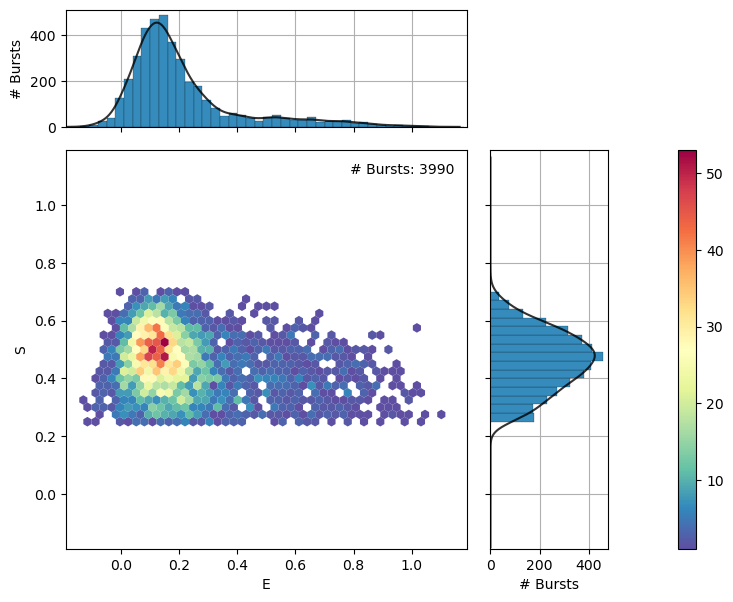

In [11]:
data_fret = data_all.select_bursts(frb.select_bursts.naa, th1=15)
data_fret = data_fret.select_bursts(frb.select_bursts.S, S1=0.25, S2=0.7)
frb.alex_jointplot(data_fret);

Now we need to make selections for each subpopulation.

> **NOTE**
>
> Each decay must be linearly independant from the others.
> So the number of final selections should change depending on the number of species in the data.
> This means removing or adding selections.
> *You cannot leave "dummy" selections* which are the same as nother, this will cause a singular matrix error when calculating the weights function.

The example contains open and closed haripin, many of the bursts are undergoing dynamics, so we will select the extremes of E to get the open (low E) and closed (high E) subpopulations.

**Open subpopulation**

<class 'matplotlib.figure.Figure'>


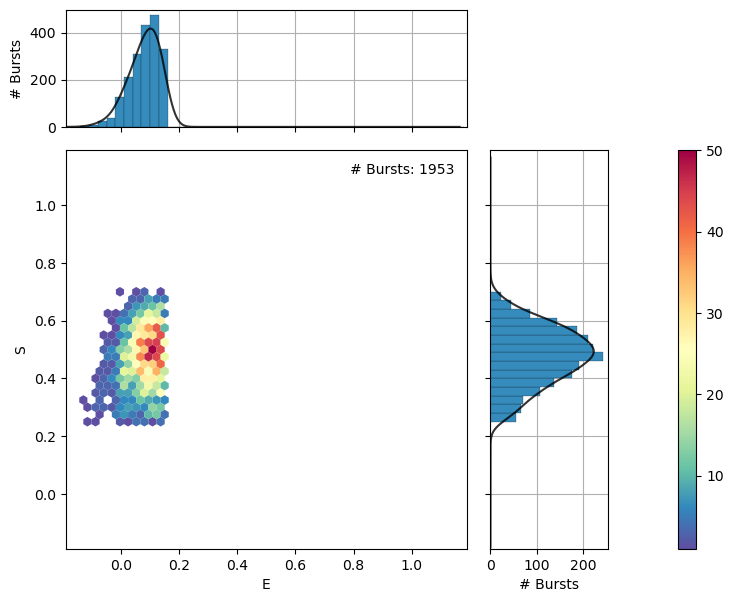

In [12]:
data_open = data_fret.select_bursts(frb.select_bursts.E, E2=0.15)
frb.alex_jointplot(data_open);

**Closed subpopulation**

<class 'matplotlib.figure.Figure'>


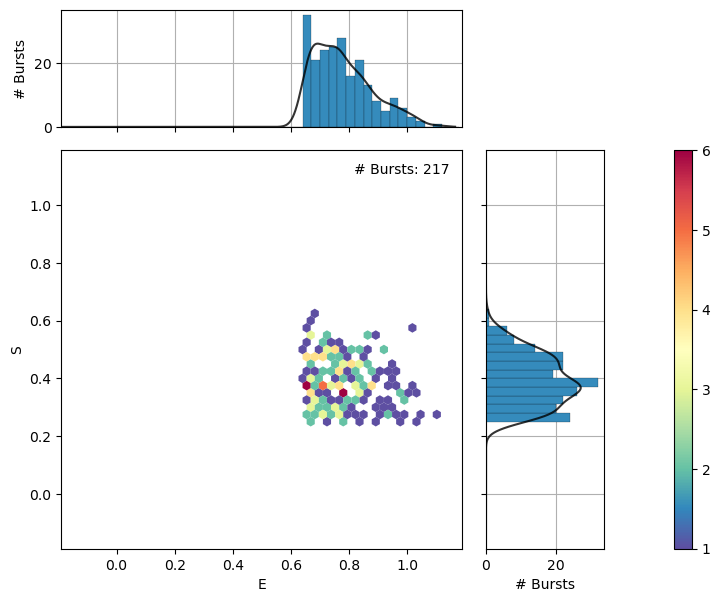

In [13]:
data_closed = data_fret.select_bursts(frb.select_bursts.E, E1=0.65)
frb.alex_jointplot(data_closed);

**Selection for Donor-Only bursts**
This is a static population, so no need to create sub-selections for each decay.

<class 'matplotlib.figure.Figure'>


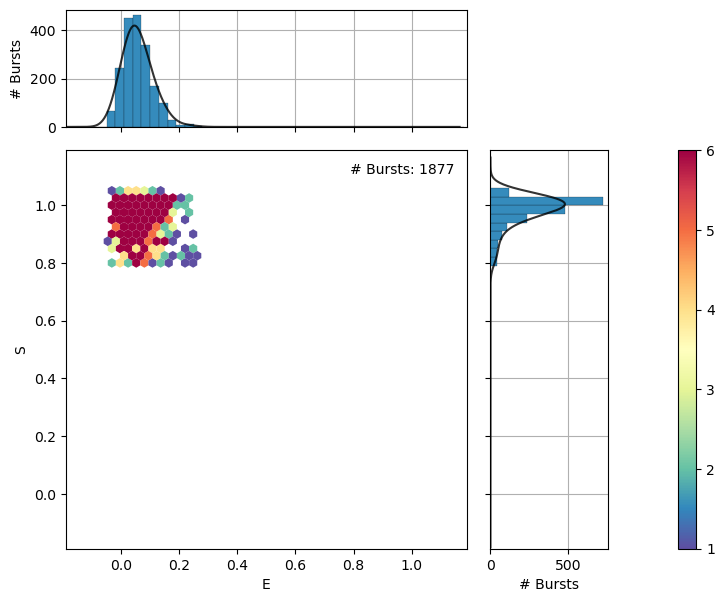

In [14]:
data_donly = data_all.select_bursts(frb.select_bursts.S, S1=0.8)
data_donly = data_donly.select_bursts(frb.select_bursts.E, E2=0.3)
frb.alex_jointplot(data_donly);

**Selection for acceptor only bursts**

<class 'matplotlib.figure.Figure'>


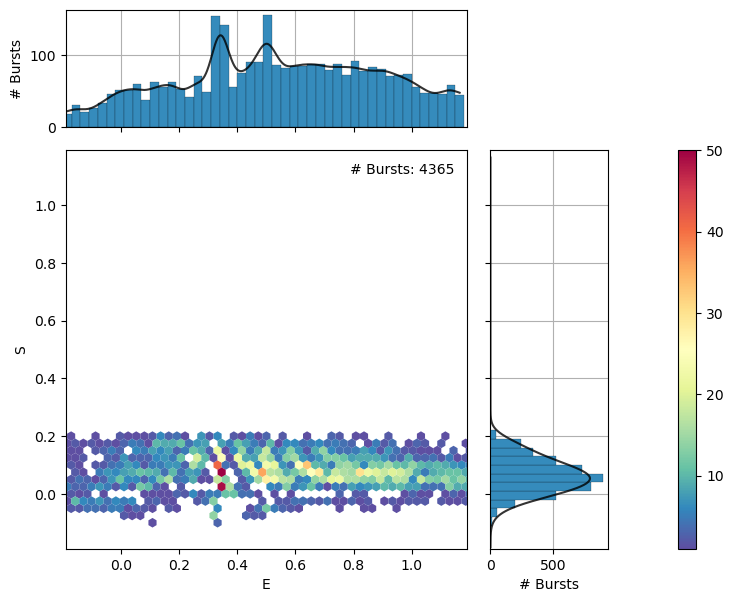

In [15]:
data_aonly = data_all.select_bursts(frb.select_bursts.S, S2=0.2)
frb.alex_jointplot(data_aonly);

**Now perform same selections on other hairpin files**

In [17]:
files = [f'{directory}/HP3_TE{conc}_SPC630.hdf5' for conc in ('50', '100', '150', '200', '250', '300', '350')]
data_list = [frb.loader.photon_hdf5(f) for f in files]
data_list_open, data_list_closed, data_list_Donly, data_list_Aonly = list(), list(), list(), list()
for d in data_list:
    frb.loader.alex_apply_period(d)
    d.calc_bg(frb.bg.exp_fit, F_bg=1.7, time_s=30)
    d.burst_search(m=10, F=6)
    d_all = d.select_bursts(frb.select_bursts.size, th1=30, add_naa=True)
    d_fret = d_all.select_bursts(frb.select_bursts.naa, th1=15)
    d_fret = d_fret.select_bursts(frb.select_bursts.S, S1=0.25, S2=0.7)
    data_list_open.append(d_fret.select_bursts(frb.select_bursts.E, E2=0.15))
    data_list_closed.append(d_fret.select_bursts(frb.select_bursts.E, E1=0.65))
    d_Donly = d_all.select_bursts(frb.select_bursts.S, S1=0.8)
    data_list_Donly.append(d_Donly.select_bursts(frb.select_bursts.E, E2=0.3))
    data_list_Aonly.append(d_all.select_bursts(frb.select_bursts.S, S2=0.2))

# Total photons (after ALEX selection):     6,470,880
#  D  photons in D+A excitation periods:    3,220,872
#  A  photons in D+A excitation periods:    3,250,008
# D+A photons in  D  excitation period:     4,109,822
# D+A photons in  A  excitation period:     2,361,058

 - Calculating BG rates ... get bg th arrays
Channel 0
[DONE]
 - Performing burst search (verbose=False) ...[DONE]
 - Calculating burst periods ...[DONE]
 - Counting D and A ph and calculating FRET ... 
   - Applying background correction.
   [DONE Counting D/A]
# Total photons (after ALEX selection):     4,812,329
#  D  photons in D+A excitation periods:    2,361,281
#  A  photons in D+A excitation periods:    2,451,048
# D+A photons in  D  excitation period:     3,088,321
# D+A photons in  A  excitation period:     1,724,008

 - Calculating BG rates ... get bg th arrays
Channel 0
[DONE]
 - Performing burst search (verbose=False) ...[DONE]
 - Calculating burst periods ...[DONE]
 - Counting D and A ph and calculating FR

<a id='2.2'></a>
## 2.2 Extract the decays and perform fits

Bellow we define a function that will extract the appropriate decays.
The inputs are 
1. first the data object with the burst selection you want (the "pure" species).
2. The photon stream (Ph_sel object) for which you want to generate a decay

<a id='2.2.1'></a>
### 2.2.1 Extracting decays

First, the cell bellow defines some functions to ease in extracting the important data.
The last function `extract_decays` is the function that will be called in the rest of the notebook.
It is the one that you will need to understand how it works.
The other functions are needed by `extract_decays` so they are necessary to make `extract_decays` work,
but you will  not need to call them directly.

below is the signature of `extract_decays`

```python
extract_decays(data, ph_sel, return_sels=False, return_data_arrays=False)
```
If `return_sels` and `return_data_arrays` are both `False`, then the output is simply an array of the TCSPC decay of bursts in `data` (a fretbursts data object, with bursts selected), in the channel `ph_sel` (a fretbursts `Ph_sel` object).

When `return_sels` is true, then two lists will be added to the output, these will be relevant in **2.3.3 Stacked decays**.

When `return_data_arrays` is True, then two arrays will be added to the output, the first is the photon macrotimes, the second is the photon nanotime (shifted so indexing starts at 0, not the nanotime window) of the given photon selection.

Below are examples of how to call the function with differing `return_sels` and `return_data_arrays` arguments:

```python
decay = extract_decays(data, frb.Ph_sel(Dex='Dem'))
# equivalent to:
decay = extract_decays(data, frb.Ph_sel(Dex='Dem'), return_sels=False, return_data_arrays=False)

decay, ph_selsDexDem, ph_rangesDexDem = extract_decays(data, frb.Ph_sel(Dex='Dem'), return_sels=True, return_data_arrays=False)

decay, timesDexDem, nanosDexDem = extract_decays(data, frb.Ph_sel(Dex='Dem'), return_sels=False, return_data_arrays=True)

decay, ph_selsDexDem, ph_rangesDexDem, timesDexDem, nanosDexDem = extract_decays(data, frb.Ph_sel(Dex='Dem'), return_sels=True, return_data_arrays=True)
```

In [18]:
######################################################################
### This cell contains a small api-like set of functions
### Those that begin with an underscore (_[name]) are intended
### for use within the main functions. As such it is not important
### that the user undertands their purpose.
### the functions that do not have the underscore prefix are intended
### for the user to call directly, and their purpose should therefore 
### be understood
######################################################################

def _subem(ph_sel, ex):
    """Take the excitation from a Ph_sel, and return all unique streams inside"""
    out = list()
    em = getattr(ph_sel, ex)
    if em is None:
        return out
    if "D" in em:
        out.append(frb.Ph_sel(**{ex:'Dem'}))
    if "A" in em:
        out.append(frb.Ph_sel(**{ex:'Aem'}))
    return out
    
def _unique_ph_sels(ph_sel):
    """Return all streams present in a Ph_sel obejct"""
    # first break down selection into single excitation, single emission
    return _subem(ph_sel, 'Dex') + _subem(ph_sel, 'Aex')
    

def _concatenate_arrays(array):
    """Converts array or list of arrays to concatenated array"""
    if not np.issubdtype(type(array[0]), np.number):
        array = np.concatenate(array)
    return np.asarray(array)

def _shift_data(data, shifts, ph_sels, ph_sel):
    nanos = list()
    for i in range(data.nch):
        mask = data.get_ph_mask(ich=i, ph_sel=ph_sel)
        nanos = data.nanotimes[i][mask].astype(np.int32)
        for shift, sel in zip(shifts, ph_sels):
            msk = data.get_ph_mask(ich=i, ph_sel=sel)[mask]
            nanos[msk] += shift
    times = tuple(data.iter_ph_times(ph_sel=ph_sel))
    return times, nanos

##############################
### IMPORTANT FUCNTIONS BELLOW
##############################
def calculate_shifts(data, ph_sel, return_sels=True, return_ranges=True):
    """
    Generate array of values by which to shift the nanotimes of individual
    streams in a given Ph_sel to generate "stacked" arrays with no gaps
    Arguments
    ---------
    data: frb.Data
        The data object, used to get the D_ON and A_ON values
    ph_sel: frb.Ph_sel
        The potentially multi-stream Ph_sel for which shifts should be calculated
    return_sels: bool (optional)
        Whether or not to return the ph_sel corresponding to each stream in the ph_sel
        (Maintains order of shift), the default is True
    return_ranges: bool (optional)
        Whether or not to return slices corresponding to the range of a each
        stream in the ph_sel (Maintains order of shift). The default is True
    Returns
    -------
    shifts: list[int]
        The integer to add to the nanotimes of each stream in ph_sels to
        create stacked array
    ph_sels: list[frb.Ph_sel] (optional)
        The Ph_sel of each stream in ph_sel
    ph_sel_ranges: list[frb.Ph_sel] (optional)
        The range in the decay of each stream, returned as a slice
    """
    ph_sels = _unique_ph_sels(ph_sel)
    shift = list()
    shift_base = 0
    ph_sel_ranges = list()
    ranges_start = 0
    for sel in ph_sels:
        start, stop = data.D_ON if sel.Dex else data.A_ON
        shift.append(shift_base-start-1)
        shift_base += stop - start - 1
        ph_sel_ranges.append(slice(ranges_start, stop-start+1+ranges_start))
        ranges_start += stop-start+1
    out = [shift, ]
    if return_sels:
        out.append(ph_sels)
    if return_ranges:
        out.append(ph_sel_ranges)
    if return_ranges or return_sels:
        out = tuple(out)
    else:
        out = out[0]
    return out


###############################################################
### This is the function you will use most in the data analysis
###############################################################
def extract_decays(data, ph_sel, return_sels=False, return_data_arrays=False):
    """
    Extract the TCSPC histogram of a given photon stream for photons within
    bursts in a given data object

    Arguments:
    ----------
    data: frb.Data
        The (burst-selected) data
    ph_sel: frb.Ph_sel
        The desired photon stream
    return_sels: bool (optional)
        Whether or not to return a list of the streams inside
        the ph_sel object, and a list of slice objects defining
        the ranges with in the decay for each corresponding
        stream. The default is False
    return_data_arrays: bool, (optional)
        Whether or not to return the times and nanotimes data
        filtered by the given ph_sel. Note that nanotimes are
        shifted so that TCSPC starts at 0, if multiple streams
        are present in the ph_sel, then nanotimes are stacked
        so that each channel has unique range of nanotimes.
        The default is False
    Returns:
    --------
    decay: np.ndarray
        TCSPC histogram of nanotimes in bursts of selected photon stream
    ph_sels: list[frb.Ph_sel] (if return_sels=True)
        The Ph_sels (in order of appearance in decay and ranges) of the
        streams in the ph_sel input
    ph_sel_ranges: list[slice] (if return_sels=True)
        Slice objects for isolating the individual decays of each stream
        within the decay array
    times: list[np.ndarray] (if return_data_arrays=True)
        The photon macrotimes of all photons in ph_sel
    nanos: list[np.ndarray] (if return_data_arrays=True)
        The photon nanotimes of all photons in ph_sel, shifted so that
        each stream is "stacked" into a single array.
    """
    nanos = list()
    shifts, ph_sels, ph_sel_ranges = calculate_shifts(data, ph_sel)
    for i in range(data.nch):
        nanotimes = data.nanotimes[i].astype(np.int32)
        for start, stop in zip(data.mburst[i].istart, data.mburst[i].istop+1):
            for shift, sel in zip(shifts, ph_sels):
                mask = data.get_ph_mask(ich=i, ph_sel=sel)
                nanos.append(nanotimes[start:stop][mask[start:stop]]+shift)
    minlength = sum(np.diff(data.D_ON if sel.Dex else data.A_ON)[0]-1 for sel in ph_sels)
    decay = np.bincount(np.concatenate(nanos), minlength=minlength)
    out = [decay, ]
    if return_sels:
        out += [ph_sels, ph_sel_ranges]
    if return_data_arrays:
        timesnanos = _shift_data(data, shifts, ph_sels, ph_sel)
        out += timesnanos
    if not return_data_arrays and not return_sels:
        out = out[0]
    return out

Now let's extract the decays for the $D_{ex}D_{em}$ stream, and plot for each selections.

> **Note**
>
> Since the open population has a low FRET value,
> it's lifetime will be only slightly less than that of the Donor only subpopulation.
> This means the FLCS algorithm will be less effective at distinguishing these species.

Text(0, 0.5, 'norm counts')

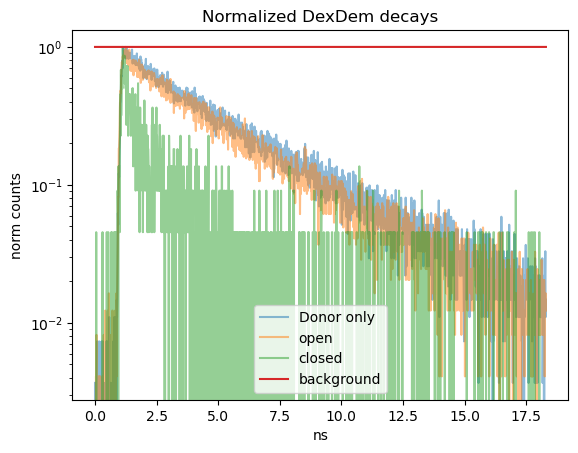

In [19]:
# generate decays for each species from relevant burst selections
decay_donly_DD, phsels_DD, phrngs_DD, timesDD, nanosDD = extract_decays(data_donly, frb.Ph_sel(Dex='Dem'), return_data_arrays=True, return_sels=True)
decay_aonly_DD = extract_decays(data_aonly, frb.Ph_sel(Dex='Dem'))
decay_open_DD = extract_decays(data_open, frb.Ph_sel(Dex='Dem'))
decay_closed_DD = extract_decays(data_closed, frb.Ph_sel(Dex='Dem'))
bg_D = np.ones(decay_donly_DD.size) # standard practice is to include a flat decay to account for background photons

# preparations for plotting
# first make array for the x-values (ie nanotime of each TCSPC bin)
x_nanotimes_D = np.arange(decay_donly_DD.size)*data_donly.nanotimes_params[0]['tcspc_unit']*1e9
# ploting, note that all decays are normalized to max, so that they can be compared more easily
plt.semilogy(x_nanotimes_D, decay_donly_DD/decay_donly_DD.max(), label='Donor only', alpha=0.5)
plt.semilogy(x_nanotimes_D, decay_open_DD/decay_open_DD.max(), label='open', alpha=0.5)
plt.semilogy(x_nanotimes_D, decay_closed_DD/decay_closed_DD.max(), label='closed', alpha=0.5)
plt.semilogy(x_nanotimes_D, bg_D, label='background')
plt.legend()
plt.title("Normalized DexDem decays")
plt.xlabel("ns")
plt.ylabel("norm counts")

Now for the $D_{ex}A_{em}$ photons.

Text(0, 0.5, 'norm counts')

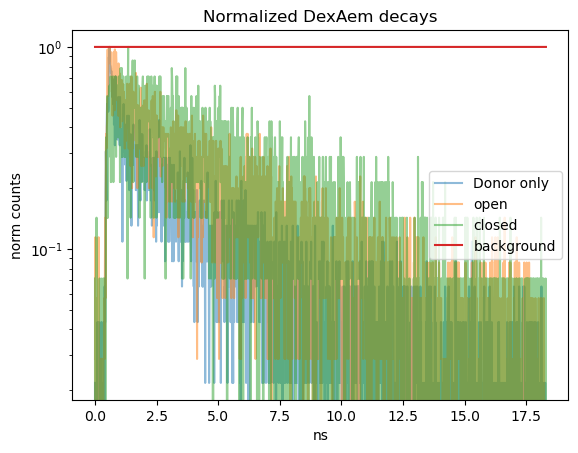

In [20]:
# generate decays for each species from relevant burst selections
decay_donly_DA, phsels_DA, phrngs_DA, timesDA, nanosDA = extract_decays(data_donly, frb.Ph_sel(Dex='Aem'), return_data_arrays=True, return_sels=True)
decay_aonly_DA = extract_decays(data_aonly, frb.Ph_sel(Dex='Aem'))
decay_open_DA = extract_decays(data_open, frb.Ph_sel(Dex='Aem'))
decay_closed_DA = extract_decays(data_closed, frb.Ph_sel(Dex='Aem'))
# the bg_D decay is commented out because for a given excitation, the size will always be the same
# so the previous definition from DexDem will work
# bg_D = np.ones(decay_aonly_DA.size) # standard practice is to include a flat decay to account for background photons

# preparations for plotting
# first make array for the x-values (ie nanotime of each TCSPC bin)
# commented out, because like for bg_D, this was also made in the DexDem selection
# x_nanotimes_D = np.arange(decay_donly_DD.size)*data_donly.nanotimes_params[0]['tcspc_unit']*1e9
# ploting
plt.semilogy(x_nanotimes_D, decay_donly_DA/decay_donly_DA.max(), label='Donor only', alpha=0.5)
plt.semilogy(x_nanotimes_D, decay_open_DA/decay_open_DA.max(), label='open', alpha=0.5)
plt.semilogy(x_nanotimes_D, decay_closed_DA/decay_closed_DA.max(), label='closed', alpha=0.5)
plt.semilogy(x_nanotimes_D, bg_D, label='background')
plt.legend()
plt.title("Normalized DexAem decays")
plt.xlabel("ns")
plt.ylabel("norm counts")

Now we make the final $A_{ex}A_{em}$ decays. This time we exclude the D-only selection but include the A-only.

> **Note**
>
> Since the $A_{ex}A_{em}$ emission is essentially unaffected by the presence or absence of a (blinked) donor,
> these decays will be nearly identical, and thus will not produce good (or even viable) weighting functions.
> They are showed here, but the notebook will not perform FLCS on the $A_{ex}A_{em}$ data.

Text(0, 0.5, 'norm counts')

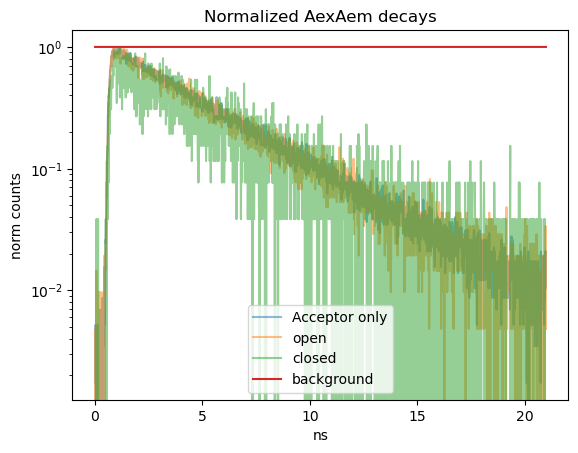

In [21]:
# generate decays for each species from relevant burst selections
decay_donly_AA, phsels_AA, phrngs_AA, timesAA, nanosAA = extract_decays(data_donly, frb.Ph_sel(Aex='Aem'), return_data_arrays=True, return_sels=True)
decay_aonly_AA = extract_decays(data_aonly, frb.Ph_sel(Aex='Aem'))
decay_open_AA = extract_decays(data_open, frb.Ph_sel(Aex='Aem'))
decay_closed_AA = extract_decays(data_closed, frb.Ph_sel(Aex='Aem'))
bg_A = np.ones(decay_aonly_AA.size) # standard practice is to include a flat decay to account for background photons

# preparations for plotting
# first make array for the x-values (ie nanotime of each TCSPC bin)
x_nanotimes_A = np.arange(decay_aonly_AA.size)*data_aonly.nanotimes_params[0]['tcspc_unit']*1e9
# ploting, note that all decays are normalized to max, so that they can be compared more easily
plt.semilogy(x_nanotimes_A, decay_aonly_AA/decay_aonly_AA.max(), label='Acceptor only', alpha=0.5)
plt.semilogy(x_nanotimes_A, decay_open_AA/decay_open_AA.max(), label='open', alpha=0.5)
plt.semilogy(x_nanotimes_A, decay_closed_AA/decay_closed_AA.max(), label='closed', alpha=0.5)
plt.semilogy(x_nanotimes_A, bg_A, label='background')
plt.legend()
plt.title("Normalized AexAem decays")
plt.xlabel("ns")
plt.ylabel("norm counts")

### 2.2.1 Exponential fitting

When generating filters, there are two options:
1. Use decay histograms directly (usually with background subtraction), which preserve all complexities, but have issue of noise
2. Use exponential fitting to obtain smoother decays, but potentially remove important features such as minor multi-exponential decay components.

This notebook will perform both. 
Since the "pure" decays all look fairly mono-exponential, to reduce complexity,
we will only fit with mono-exponential functions.
This may not be the case with your data, and you should adjust your decay fitting functions appropriately

**Define functions for fitting**

In [22]:
def single_exp(vals, x, norm=False):
    """
    Function for calculating single exponential decay function with a Gaussian IRF
    Calcualted for values in x
    Arguments
    ---------
    vals: (float, float, float)
        A 3 tuple of the (center, sigma tau) where:
        center: the center of the IRF
        sigma: the standard deviation of the IRF
        tau: the lifetime of the exponential decay
    x: np.ndarray
        The X values for the evaluation
    Returns
    -------
    decay: np.ndarray
        the decay function, size of x
    """
    c, sigma, tau  = vals
    irf = stats.norm.pdf(x, loc=c, scale=sigma)
    dec = 1/tau*np.exp(-x/tau)
    decay = np.convolve(irf, dec, mode='fill')[:x.size]
    if norm:
        decay = decay / decay.sum()
    return decay

def single_exp_min(vals, y):
    """
    Function calculating the Xi-square value of a single exponential fit
    to tcspc decay, using a single exponential function.
    Arguments
    ---------
    vals: (float, float, float)
        A 3 tuple of the (center, sigma tau) where:
        center: the center of the IRF
        sigma: the standard deviation of the IRF
        tau: the lifetime of the exponential decay
    y: np.ndarray
        The values of the TCSPC decay in the real data
    Returns
    -------
    sum of squares difference between fit and input decay
    """
    y = np.asarray(y)
    bg = y[:20].mean()*1.5
    msk = y>bg
    y = y / y[msk].sum()
    x = np.arange(0,y.size,1)
    dec = single_exp(vals, x)
    dec = dec / dec.sum()
    return np.sum((dec[msk]-y[msk])**2)

def global_single_exp_min(vals, *args):
    """
    Functon for global fitting of several decays. Fits lifetimes independently, but
    ensure IRF same for all.
    Arguments
    ---------
    vals: tuple[float]
        A N+1 tuple of the (center, sigma tau0, tau1 ...) where:
        center: the center of the IRF
        sigma: the standard deviation of the IRF
        tauN: the lifetimes of the exponential decays
    args: tuple[np.ndarray]
        The values of the TCSPC decays in the real data
    Returns
    -------
    sum of squares difference between fit and input decays
    
    """
    vals = np.asarray(vals)
    if vals.size - 2 != len(args):
        raise ValueError("number of decays mismatch with vals input")
    args = tuple(np.asarray(arg) for arg in args)
    if any(args[0].shape != arg.shape for arg in args[1:]):
        raise ValueError("args must all be same length")
    c, sigma = vals[0], vals[1]
    return sum(single_exp_min((c, sigma, tau), dec) for tau, dec in zip(vals[2:], args))    

#### 2.2.1.1 Fittings for $D_{ex}D_{em}$ decays, in detail

**Single exponential fitting of D-only $D_{ex}D_{em}$ species**

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 2.6452939686467913e-05
        x: [ 9.000e+01  4.000e+00  3.100e+02]
      nit: 0
      jac: [ 5.022e-06 -1.537e-06 -4.449e-08]
 hess_inv: [[1 0 0]
            [0 1 0]
            [0 0 1]]
     nfev: 4
     njev: 1

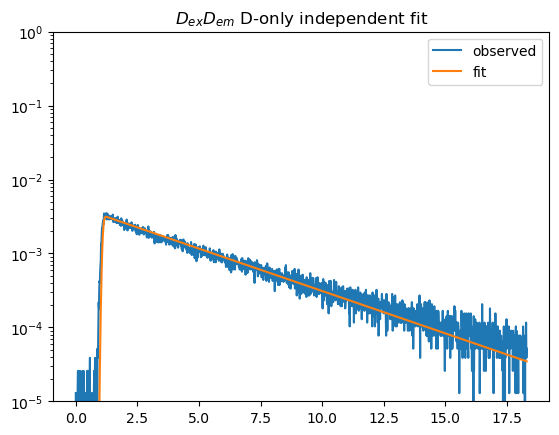

In [23]:
initial_donly_DD = np.array([90, 4, 310]) # initial guess for fitting, order is center, sigma, tau, tau in TCSPC units
res_donly_DD = optimize.minimize(single_exp_min, initial_donly_DD, args=(decay_donly_DD,))

plt.semilogy(x_nanotimes_D, decay_donly_DD/decay_donly_DD.sum(), label='observed')
plt.semilogy(x_nanotimes_D, single_exp(res_donly_DD.x, np.arange(0,decay_donly_DD.size,1), norm=True), label='fit')
plt.ylim([1e-5, 1])
plt.legend()
plt.title(r"$D_{ex}D_{em}$ D-only independent fit")
res_donly_DD

**Single exponential fitting of open $D_{ex}D_{em}$ species**

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.0014100243626202573
        x: [ 7.797e+01  5.163e+00  2.487e+02]
      nit: 3
      jac: [-3.659e-06  4.644e-06  4.344e-06]
 hess_inv: [[ 2.362e+05  9.498e+04  2.501e+04]
            [ 9.498e+04  3.819e+04  1.006e+04]
            [ 2.501e+04  1.006e+04  2.649e+03]]
     nfev: 48
     njev: 12

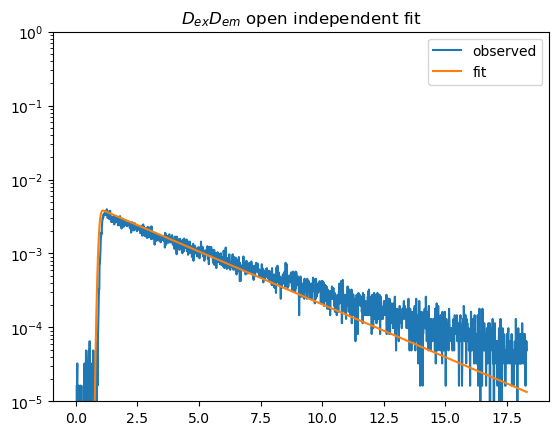

In [24]:
initial_open_DD = np.array([90, 10, 250])
res_open_DD = optimize.minimize(single_exp_min, initial_open_DD, args=(decay_closed_DD,))

plt.semilogy(x_nanotimes_D, decay_open_DD/decay_open_DD.sum(), label='observed')
plt.semilogy(x_nanotimes_D, single_exp(res_open_DD.x, np.arange(0,decay_open_DD.size,1), norm=True), label='fit')
plt.ylim([1e-5, 1])
plt.legend()
plt.title(r"$D_{ex}D_{em}$ open independent fit")
res_open_DD

**Single exponential fitting of closed $D_{ex}D_{em}$ species**

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.000989874380728498
        x: [ 8.033e+01  8.714e+00  9.091e+01]
      nit: 3
      jac: [-5.500e-06  6.119e-06 -7.013e-06]
 hess_inv: [[ 1.427e+05  1.897e+04 -1.339e+04]
            [ 1.897e+04  2.523e+03 -1.780e+03]
            [-1.339e+04 -1.780e+03  1.257e+03]]
     nfev: 44
     njev: 11

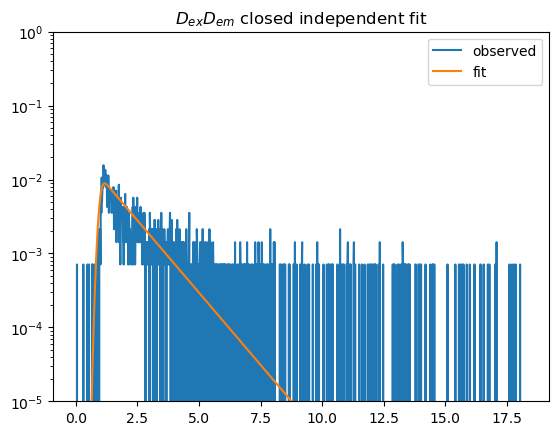

In [25]:
initial_closed_DD = np.array([90, 10, 90])
res_closed_DD = optimize.minimize(single_exp_min, initial_closed_DD, args=(decay_closed_DD,))

plt.semilogy(x_nanotimes_D, decay_closed_DD/decay_closed_DD.sum(), label='observed')
plt.semilogy(x_nanotimes_D, single_exp(res_closed_DD.x, np.arange(0,decay_closed_DD.size,1), norm=True), label='fit')
plt.ylim([1e-5, 1])
plt.legend()
plt.title(r"$D_{ex}D_{em}$ closed independent fit")
res_closed_DD

**Global fitting of values**

  message: Optimization terminated successfully.
  success: True
   status: 0
      fun: 0.000952551606527906
        x: [ 8.323e+01  4.219e+00  3.007e+02  2.534e+02  1.234e+02]
      nit: 50
      jac: [ 1.765e-06  3.910e-06 -2.840e-07 -1.141e-06  1.411e-06]
 hess_inv: [[ 1.240e+05 -4.790e+04 ... -1.359e+04 -3.268e+05]
            [-4.790e+04  1.576e+05 ... -2.077e+04 -1.661e+05]
            ...
            [-1.359e+04 -2.077e+04 ...  1.795e+04  2.778e+05]
            [-3.268e+05 -1.661e+05 ...  2.778e+05  4.504e+06]]
     nfev: 360
     njev: 60

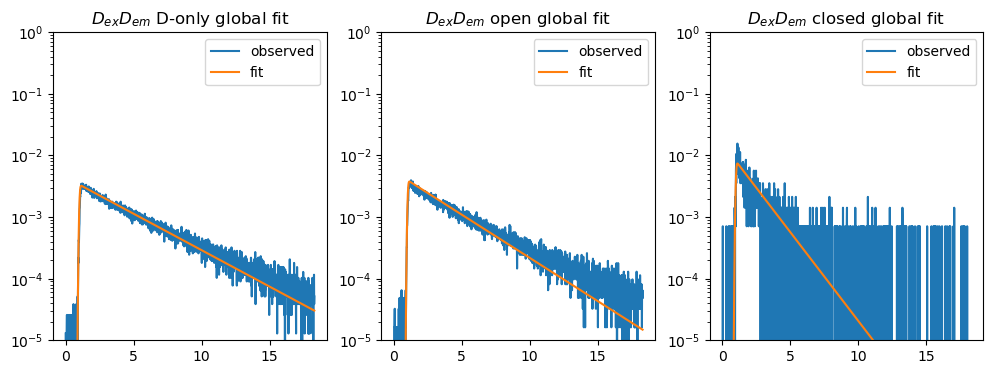

In [26]:
initial_global_DD = np.array([82.0, 6.0, 300.0, 250.0, 70.0])
res_global_DD = optimize.minimize(global_single_exp_min, initial_global_DD, args=(decay_donly_DD, decay_open_DD, decay_closed_DD))
res_global_DD

fig, ax = plt.subplots(1,3, figsize=(12,4))

ax[0].semilogy(x_nanotimes_D, decay_donly_DD/decay_donly_DD.sum(), label='observed')
ax[0].semilogy(x_nanotimes_D, single_exp((res_global_DD.x[0], res_global_DD.x[1], res_global_DD.x[2]), np.arange(0,decay_donly_DD.size,1), norm=True), label='fit')
ax[0].set_title("$D_{ex}D_{em}$ D-only global fit")

ax[1].semilogy(x_nanotimes_D, decay_open_DD/decay_open_DD.sum(), label='observed')
ax[1].semilogy(x_nanotimes_D, single_exp((res_global_DD.x[0], res_global_DD.x[1], res_global_DD.x[3]), np.arange(0,decay_open_DD.size,1), norm=True), label='fit')
ax[1].set_title("$D_{ex}D_{em}$ open global fit")

ax[2].semilogy(x_nanotimes_D, decay_closed_DD/decay_closed_DD.sum(), label='observed')
ax[2].semilogy(x_nanotimes_D, single_exp((res_global_DD.x[0], res_global_DD.x[1], res_global_DD.x[4]), np.arange(0,decay_closed_DD.size,1), norm=True), label='fit')
ax[2].set_title("$D_{ex}D_{em}$ closed global fit")

for a in ax:
    a.set_ylim([1e-5, 1])
    a.legend()

res_global_DD

#### 2.2.1.2 Fittings for $D_{ex}A_{em}$ decays

The method is identical to before, so we'll combine cells together to save space.

First we'll do the single exponential independent fits:

(  message: Optimization terminated successfully.
   success: True
    status: 0
       fun: 0.0007671517277978763
         x: [ 3.643e+01  3.038e+01  1.224e+02]
       nit: 5
       jac: [ 4.002e-06 -2.589e-07 -8.926e-06]
  hess_inv: [[ 1.396e+04 -1.072e+05 -8.784e+04]
             [-1.072e+05  8.236e+05  6.747e+05]
             [-8.784e+04  6.747e+05  5.527e+05]]
      nfev: 52
      njev: 13,
   message: Optimization terminated successfully.
   success: True
    status: 0
       fun: 0.00017887031062261834
         x: [ 4.000e+01  4.000e+00  3.100e+02]
       nit: 0
       jac: [ 4.763e-06  1.716e-06 -2.667e-07]
  hess_inv: [[1 0 0]
             [0 1 0]
             [0 0 1]]
      nfev: 4
      njev: 1,
   message: Optimization terminated successfully.
   success: True
    status: 0
       fun: 0.0005179393532076615
         x: [ 4.000e+01  4.000e+00  2.500e+02]
       nit: 0
       jac: [-3.613e-06 -6.186e-06 -3.909e-06]
  hess_inv: [[1 0 0]
             [0 1 0]
             [0 0 1

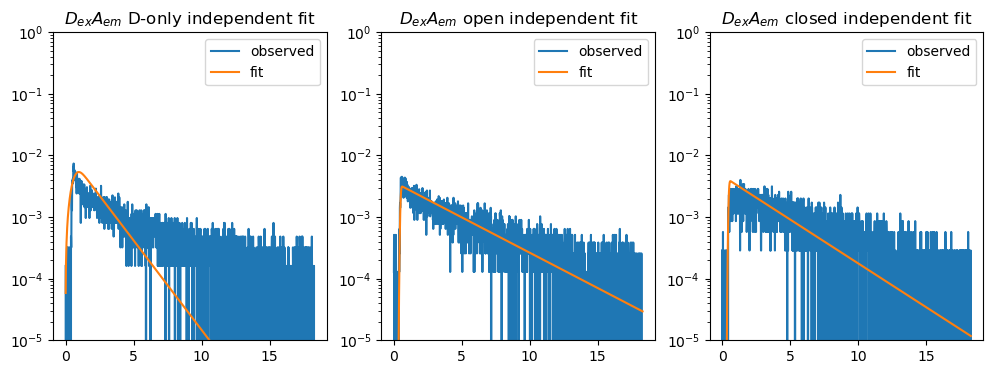

In [27]:
initial_donly_DA = np.array([40, 3, 100]) # initial guess for fitting, order is center, sigma, tau, tau in TCSPC units
res_donly_DA = optimize.minimize(single_exp_min, initial_donly_DA, args=(decay_donly_DA,))

initial_open_DA = np.array([40, 4, 310]) # initial guess for fitting, order is center, sigma, tau, tau in TCSPC units
res_open_DA = optimize.minimize(single_exp_min, initial_open_DA, args=(decay_open_DA,))

initial_closed_DA = np.array([40, 4, 250]) # initial guess for fitting, order is center, sigma, tau, tau in TCSPC units
res_closed_DA = optimize.minimize(single_exp_min, initial_closed_DA, args=(decay_closed_DA,))

fig, ax = plt.subplots(1,3, figsize=(12,4))

ax[0].semilogy(x_nanotimes_D, decay_donly_DA/decay_donly_DA.sum(), label='observed')
ax[0].semilogy(x_nanotimes_D, single_exp(res_donly_DA.x, np.arange(0,decay_donly_DA.size,1), norm=True), label='fit')
ax[0].set_title(r"$D_{ex}A_{em}$ D-only independent fit")

ax[1].semilogy(x_nanotimes_D, decay_open_DA/decay_open_DA.sum(), label='observed')
ax[1].semilogy(x_nanotimes_D, single_exp(res_open_DA.x, np.arange(0,decay_open_DA.size,1), norm=True), label='fit')
ax[1].set_title(r"$D_{ex}A_{em}$ open independent fit")

ax[2].semilogy(x_nanotimes_D, decay_closed_DA/decay_closed_DA.sum(), label='observed')
ax[2].semilogy(x_nanotimes_D, single_exp(res_closed_DA.x, np.arange(0,decay_closed_DA.size,1), norm=True), label='fit')
ax[2].set_title(r"$D_{ex}A_{em}$ closed independent fit")

for a in ax:
    a.legend()
    a.set_ylim([1e-5, 1])

res_donly_DA, res_open_DA, res_closed_DA

## 2.3 Auto-Correlation in FLCS

### 2.3.1 Compute Weights arrays

The next step, now that we have either real data, or fitted decays, is to generate the appropriate filter functions.
These filter functions form an orthonormal basis set, and depend both on the total number of photons in each TCSPC bin
in the **data-set being correlated** and the decay curves of each species.

The `compute_weights` functions implements equation 5 from [Ghosh et. al. 2018](https://doi.org/10.1016/j.ymeth.2018.02.009):

$f = [\widehat{M} \cdot diag<I>^{-1} \cdot \widehat{M}^{T}]^{-1} \widehat{M} \cdot diag<I>^{-1}$

where $\widehat{M}$ is the matrix with column vectors of the (normalized) decays,
and $diag<I>^{-1}$ is a diagonal matrix with diagonal elements $<I_{j}>^{-1}$
where $j$ is the TCSPC bin, and $I$ indicates the intensity of the given channel in the dataset.

It can be shown if the photons have poisson statistics that this will create an orthonormal basis set
that minimizes the errors of eq. 4 of [Ghosh et. al. 2018](https://doi.org/10.1016/j.ymeth.2018.02.009).

In [28]:
def compute_weights(nanos, *args):
    """
    Compute the orthonormal set of weights arrays given the nanotimaes and the decays.
    Arguments:
    ----------
    nanos: np.ndarray
        The array of nanotimes used in the data. Note: to count the number of instances
        of each nanotime, so input the data used in correlation.
    *args: np.ndarray
        The decay histograms of each decay. Note that since the output is
        an orthonormal basis set, adding additional arguments changes all
        previous outputs, ie ``compute_weights(nanos, decay1, decay2)
        will give different weights for decay1 and decay2 compared with
        compute_weights(nanos, decay1, decay2, decay3). Must supply at least
        2 decays
    Returns:
    --------
    U: np.ndarray
        2D array of weights arranged [decayN, tcspc_bin], so the vectors
        from U[0,:], U[1,:] ... form an orthonormal basis set
    """
    # so that lists of arrays can be inputed directly
    nanos = _concatenate_arrays(nanos)
    # normalize decays and form into matrix M
    M = np.vstack([arg/arg.sum() for arg in args])
    # compute <I_{i}>
    nanodist = np.bincount(nanos, minlength=M.shape[1])
    nanodist[nanodist==0] = 1
    dIinv = 1/nanodist
    # final computation of [M diag<I>^{-1} M^{T}]^{-1} M diag<I> 
    Mi = M*dIinv # M diag<I?^{-1}
    U = np.linalg.inv(Mi@M.T) @ Mi
    return U

Now we use the compute weights function to generate the weights arrays.
Then we will plot these filter functions to determine if they look reasonable

> **Note**
>
> The output of `compute_weights` is a 2D array, shape `[decay, TCSPC_bin]`
> This can be used directly in `fcs.correlate`
>

#### 2.3.1.1 Compute weights for $D_{ex}D_{em}$ emission

Text(0, 0.5, 'weight')

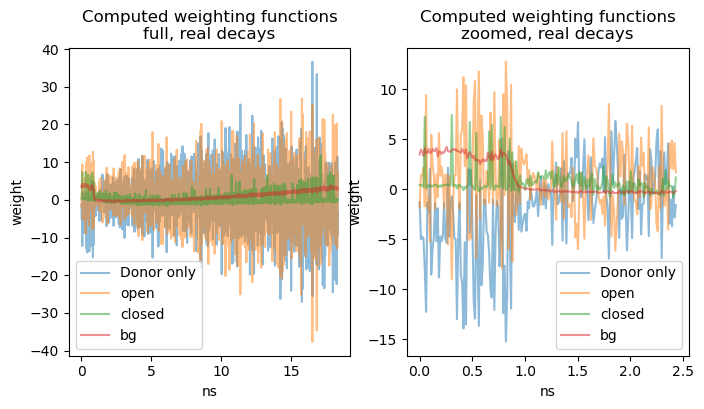

In [29]:
# Compute the weights
weights_DD = compute_weights(nanosDD, decay_donly_DD, decay_open_DD, decay_closed_DD, bg_D)

fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].plot(x_nanotimes_D, weights_DD[0,:], label='Donor only', alpha=0.5)
ax[0].plot(x_nanotimes_D, weights_DD[1,:], label='open', alpha=0.5)
ax[0].plot(x_nanotimes_D, weights_DD[2,:], label='closed', alpha=0.5)
ax[0].plot(x_nanotimes_D, weights_DD[3,:], label='bg', alpha=0.5)
ax[0].legend()
ax[0].set_title("Computed weighting functions\nfull, real decays")
ax[0].set_xlabel("ns")
ax[0].set_ylabel("weight")

ax[1].plot(x_nanotimes_D[:200], weights_DD[0,:200], label='Donor only', alpha=0.5)
ax[1].plot(x_nanotimes_D[:200], weights_DD[1,:200], label='open', alpha=0.5)
ax[1].plot(x_nanotimes_D[:200], weights_DD[2,:200], label='closed', alpha=0.5)
ax[1].plot(x_nanotimes_D[:200], weights_DD[3,:200], label='bg', alpha=0.5)
ax[1].legend()
ax[1].set_title("Computed weighting functions\nzoomed, real decays")
ax[1].set_xlabel("ns")
ax[1].set_ylabel("weight")

Text(0, 0.5, 'weight')

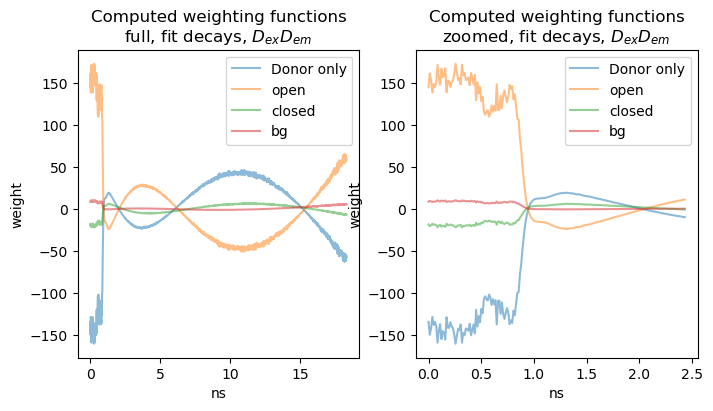

In [30]:
# Compute the weights
decay_bins = np.arange(0,decay_donly_DD.size,1)
fit_donly_DD = single_exp([res_global_DD.x[0], res_global_DD.x[1], res_global_DD.x[2]], decay_bins)
fit_open_DD = single_exp([res_global_DD.x[0], res_global_DD.x[1], res_global_DD.x[3]], decay_bins)
fit_closed_DD = single_exp([res_global_DD.x[0], res_global_DD.x[1], res_global_DD.x[4]], decay_bins)
weights_DD_fit = compute_weights(nanosDD, fit_donly_DD, fit_open_DD, fit_closed_DD, bg_D)

fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].plot(x_nanotimes_D, weights_DD_fit[0,:], label='Donor only', alpha=0.5)
ax[0].plot(x_nanotimes_D, weights_DD_fit[1,:], label='open', alpha=0.5)
ax[0].plot(x_nanotimes_D, weights_DD_fit[2,:], label='closed', alpha=0.5)
ax[0].plot(x_nanotimes_D, weights_DD_fit[3,:], label='bg', alpha=0.5)
ax[0].legend()
ax[0].set_title("Computed weighting functions\nfull, fit decays, $D_{ex}D_{em}$")
ax[0].set_xlabel("ns")
ax[0].set_ylabel("weight")

ax[1].plot(x_nanotimes_D[:200], weights_DD_fit[0,:200], label='Donor only', alpha=0.5)
ax[1].plot(x_nanotimes_D[:200], weights_DD_fit[1,:200], label='open', alpha=0.5)
ax[1].plot(x_nanotimes_D[:200], weights_DD_fit[2,:200], label='closed', alpha=0.5)
ax[1].plot(x_nanotimes_D[:200], weights_DD_fit[3,:200], label='bg', alpha=0.5)
ax[1].legend()
ax[1].set_title("Computed weighting functions\nzoomed, fit decays, $D_{ex}D_{em}$")
ax[1].set_xlabel("ns")
ax[1].set_ylabel("weight")

#### 2.3.1.1 Compute weights for $D_{ex}A_{em}$ emission

Text(0, 0.5, 'weight')

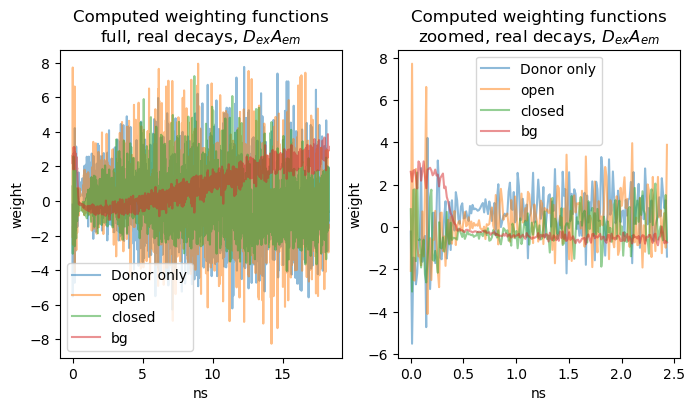

In [31]:
# Compute the weights
weights_DA = compute_weights(nanosDA, decay_donly_DA, decay_open_DA, decay_closed_DA, bg_D)

fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].plot(x_nanotimes_D, weights_DA[0,:], label='Donor only', alpha=0.5)
ax[0].plot(x_nanotimes_D, weights_DA[1,:], label='open', alpha=0.5)
ax[0].plot(x_nanotimes_D, weights_DA[2,:], label='closed', alpha=0.5)
ax[0].plot(x_nanotimes_D, weights_DA[3,:], label='bg', alpha=0.5)
ax[0].legend()
ax[0].set_title("Computed weighting functions\nfull, real decays, $D_{ex}A_{em}$")
ax[0].set_xlabel("ns")
ax[0].set_ylabel("weight")

ax[1].plot(x_nanotimes_D[:200], weights_DA[0,:200], label='Donor only', alpha=0.5)
ax[1].plot(x_nanotimes_D[:200], weights_DA[1,:200], label='open', alpha=0.5)
ax[1].plot(x_nanotimes_D[:200], weights_DA[2,:200], label='closed', alpha=0.5)
ax[1].plot(x_nanotimes_D[:200], weights_DA[3,:200], label='bg', alpha=0.5)
ax[1].legend()
ax[1].set_title("Computed weighting functions\nzoomed, real decays, $D_{ex}A_{em}$")
ax[1].set_xlabel("ns")
ax[1].set_ylabel("weight")

Text(0, 0.5, 'weight')

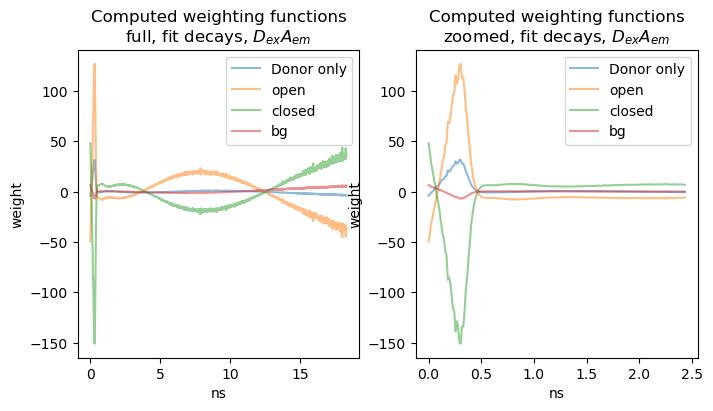

In [32]:
# Compute the weights
# decay_bins = np.arange(0,decay_donly_DA.size,1) # not necessary to remake, as same as in DD
fit_donly_DA = single_exp(res_donly_DA.x, decay_bins)
fit_open_DA = single_exp(res_open_DA.x, decay_bins)
fit_closed_DA = single_exp(res_closed_DA.x, decay_bins)
weights_DA_fit = compute_weights(nanosDA, fit_donly_DA, fit_open_DA, fit_closed_DA, bg_D)

fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].plot(x_nanotimes_D, weights_DA_fit[0,:], label='Donor only', alpha=0.5)
ax[0].plot(x_nanotimes_D, weights_DA_fit[1,:], label='open', alpha=0.5)
ax[0].plot(x_nanotimes_D, weights_DA_fit[2,:], label='closed', alpha=0.5)
ax[0].plot(x_nanotimes_D, weights_DA_fit[3,:], label='bg', alpha=0.5)
ax[0].legend()
ax[0].set_title("Computed weighting functions\nfull, fit decays, $D_{ex}A_{em}$")
ax[0].set_xlabel("ns")
ax[0].set_ylabel("weight")

ax[1].plot(x_nanotimes_D[:200], weights_DA_fit[0,:200], label='Donor only', alpha=0.5)
ax[1].plot(x_nanotimes_D[:200], weights_DA_fit[1,:200], label='open', alpha=0.5)
ax[1].plot(x_nanotimes_D[:200], weights_DA_fit[2,:200], label='closed', alpha=0.5)
ax[1].plot(x_nanotimes_D[:200], weights_DA_fit[3,:200], label='bg', alpha=0.5)
ax[1].legend()
ax[1].set_title("Computed weighting functions\nzoomed, fit decays, $D_{ex}A_{em}$")
ax[1].set_xlabel("ns")
ax[1].set_ylabel("weight")

### 2.3.2 Compute Auto-Correlation

Finally, we are ready to compute the auto-correlation.

In order to compute this, it is necessary to include the weights function and the nanotimes array(s) that go with the times arrays.
So let's see more of the signature of `fcs.correlate()`:

```python
fcs.correlate(timesT, timesU, bins, weightsT=None, weightsU=None, nanosT=None, nanosU=None)
```

For FLCS, we provide values for the `weightsT`, `weightsU`, `nanosT`, `nanosU` arguments.

`weightsT` and `weightsU` must always be specified together, and the same is true of the `nanosT` and `nanosU` arguments.

`nanosT` and `nanosU` also must match the shape of `timesT` and `timesU` respectively, as `nanosT` is the nanotimes of the photons in `timesT`, and the same is true for the `nanosU` / `timesU` pair.

`weightsT/U` can be either 1 or 2D, with the last dimension being the weights for each nanotimes (meaning the values in `nanosT/U` arrays are arrays of indexes)
If `weightsT/U` is 1D, then a single correlation will be computed, but if it is 2D, then multiple will be computed. This is convenient since a single weighting function doesn't make much sense as the point of FLCS is to separate 2 or more species from one another.

So we will have 
```python
fcs.correlate(timesT, timesU, bins, weightsT=weightsT, weightsU=weightsU, nanosT=nanosT, nanosU=nanosU)
```

Text(0, 0.5, 'G')

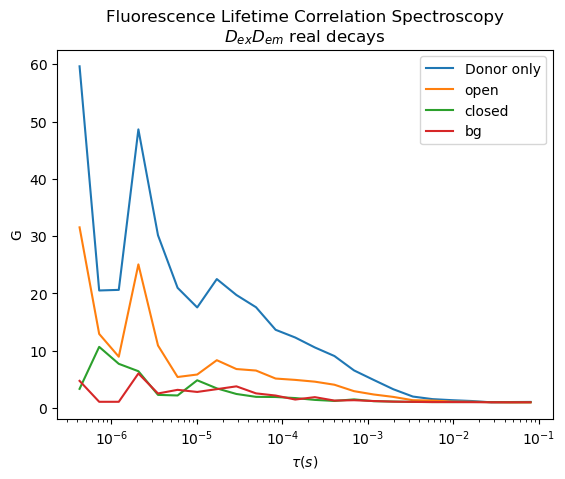

In [33]:
# compute FLCS correlations
g_DD_ltraw = fcs.correlate(timesDD, timesDD, bins, weightsT=weights_DD, weightsU=weights_DD, nanosT=nanosDD, nanosU=nanosDD)

# plot correlations
plt.semilogx(tdbins, g_DD_ltraw[0,:], label="Donor only")
plt.semilogx(tdbins, g_DD_ltraw[1,:], label="open")
plt.semilogx(tdbins, g_DD_ltraw[2,:], label="closed")
plt.semilogx(tdbins, g_DD_ltraw[3,:], label='bg')
plt.legend()
plt.title("Fluorescence Lifetime Correlation Spectroscopy\n$D_{ex}D_{em}$ real decays")
plt.xlabel(r"$\tau (s)$")
plt.ylabel("G")

Text(0, 0.5, 'G')

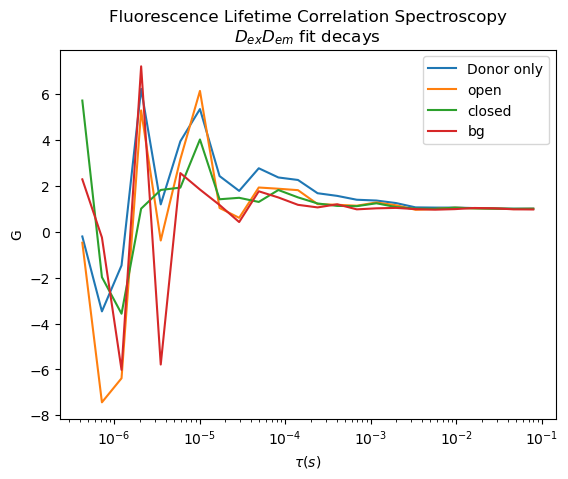

In [34]:
# compute FLCS correlations
g_DD_ltfit = fcs.correlate(timesDD, timesDD, bins, weightsT=weights_DD_fit, weightsU=weights_DD_fit, nanosT=nanosDD, nanosU=nanosDD)

# plot correlations
plt.semilogx(tdbins, g_DD_ltfit[0,:], label="Donor only")
plt.semilogx(tdbins, g_DD_ltfit[1,:], label="open")
plt.semilogx(tdbins, g_DD_ltfit[2,:], label="closed")
plt.semilogx(tdbins, g_DD_ltfit[3,:], label='bg')
plt.legend()
plt.title("Fluorescence Lifetime Correlation Spectroscopy\n$D_{ex}D_{em}$ fit decays")
plt.xlabel(r"$\tau (s)$")
plt.ylabel("G")

<a id='2.3.3'></a>
### 2.3.3 Stacked decays

A number of works have used "stacked" arrays to allow FLCS to take into account multiple streams.

The `extract_decays` function is smart, and if the input `Ph_sel` has multiple streams, it will automtically stack and adjust the nanotimes.

**First generate the decays**

Text(0, 0.5, 'norm counts')

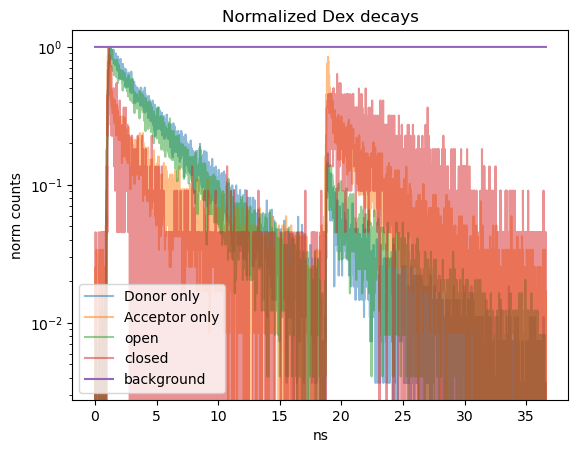

In [35]:
# generate decays for each species from relevant burst selections
decay_donly_DDDA, phsels_DDDA, phrngs_DDDA, timesDDDA, nanosDDDA = extract_decays(data_donly, frb.Ph_sel(Dex='DAem'), return_data_arrays=True, return_sels=True)
decay_aonly_DDDA = extract_decays(data_aonly, frb.Ph_sel(Dex='DAem'))
decay_open_DDDA = extract_decays(data_open, frb.Ph_sel(Dex='DAem'))
decay_closed_DDDA = extract_decays(data_closed, frb.Ph_sel(Dex='DAem'))
bg_DDA = np.ones(decay_aonly_DDDA.size) # standard practice is to include a flat decay to account for background photons

# preparations for plotting
# first make array for the x-values (ie nanotime of each TCSPC bin)
x_nanotimes_DDA = np.arange(decay_donly_DDDA.size)*data_donly.nanotimes_params[0]['tcspc_unit']*1e9
# ploting, note that all decays are normalized to max, so that they can be compared more easily
plt.semilogy(x_nanotimes_DDA, decay_donly_DDDA/decay_donly_DDDA.max(), label='Donor only', alpha=0.5)
plt.semilogy(x_nanotimes_DDA, decay_aonly_DDDA/decay_aonly_DDDA.max(), label='Acceptor only', alpha=0.5)
plt.semilogy(x_nanotimes_DDA, decay_open_DDDA/decay_open_DDDA.max(), label='open', alpha=0.5)
plt.semilogy(x_nanotimes_DDA, decay_closed_DDDA/decay_closed_DDDA.max(), label='closed', alpha=0.5)
plt.semilogy(x_nanotimes_DDA, bg_DDA, label='background')
plt.legend()
plt.title("Normalized Dex decays")
plt.xlabel("ns")
plt.ylabel("norm counts")

**Compute weights**

Text(0, 0.5, 'weight')

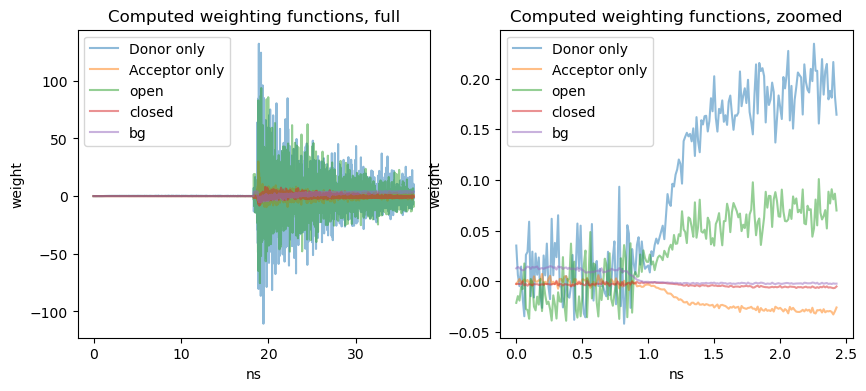

In [37]:
weights_DDDA = compute_weights(nanosDD, decay_donly_DDDA, decay_aonly_DDDA, decay_open_DDDA, decay_closed_DDDA, bg_DDA)

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(x_nanotimes_DDA, weights_DDDA[0,:], label='Donor only', alpha=0.5)
ax[0].plot(x_nanotimes_DDA, weights_DDDA[1,:], label='Acceptor only', alpha=0.5)
ax[0].plot(x_nanotimes_DDA, weights_DDDA[2,:], label='open', alpha=0.5)
ax[0].plot(x_nanotimes_DDA, weights_DDDA[3,:], label='closed', alpha=0.5)
ax[0].plot(x_nanotimes_DDA, weights_DDDA[4,:], label='bg', alpha=0.5)
ax[0].legend()
ax[0].set_title("Computed weighting functions, full")
ax[0].set_xlabel("ns")
ax[0].set_ylabel("weight")

ax[1].plot(x_nanotimes_DDA[:200], weights_DDDA[0,:200], label='Donor only', alpha=0.5)
ax[1].plot(x_nanotimes_DDA[:200], weights_DDDA[1,:200], label='Acceptor only', alpha=0.5)
ax[1].plot(x_nanotimes_DDA[:200], weights_DDDA[2,:200], label='open', alpha=0.5)
ax[1].plot(x_nanotimes_DDA[:200], weights_DDDA[3,:200], label='closed', alpha=0.5)
ax[1].plot(x_nanotimes_DDA[:200], weights_DDDA[4,:200], label='bg', alpha=0.5)

ax[1].legend()
ax[1].set_title("Computed weighting functions, zoomed")
ax[1].set_xlabel("ns")
ax[1].set_ylabel("weight")

It is clear the lack of data is resulting in very noisy fitler functions,
but we can still try to see if we can get any useful correlation data.

Text(0, 0.5, 'G')

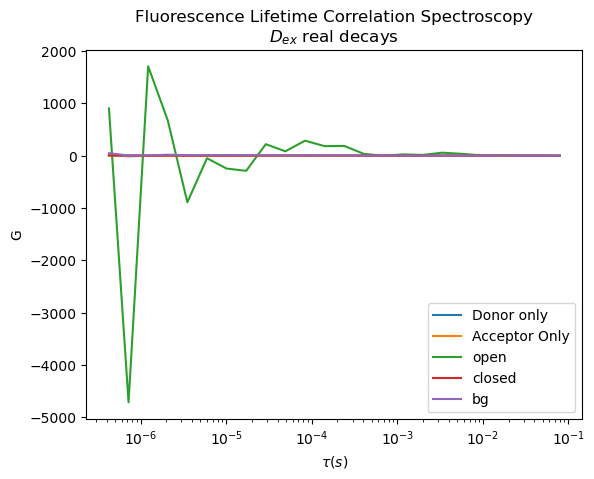

In [38]:
g_DDDA = fcs.correlate(timesDDDA, timesDDDA, bins, weightsT=weights_DDDA, weightsU=weights_DDDA, nanosT=nanosDDDA, nanosU=nanosDDDA)

plt.semilogx(tdbins, g_DDDA[0,:], label="Donor only")
plt.semilogx(tdbins, g_DDDA[1,:], label="Acceptor Only")
plt.semilogx(tdbins, g_DDDA[2,:], label="open")
plt.semilogx(tdbins, g_DDDA[3,:], label='closed')
plt.semilogx(tdbins, g_DDDA[4,:], label='bg')

plt.legend()
plt.title("Fluorescence Lifetime Correlation Spectroscopy\n$D_{ex}$ real decays")
plt.xlabel(r"$\tau (s)$")
plt.ylabel("G")

We find that due to the disparate number of photons in the different arrays, our weight functions don't function as well.
More data should help significantly.

But, we do have the fits, so we will use our fitted decays, and stack them instead to hopefully create a better filter function.

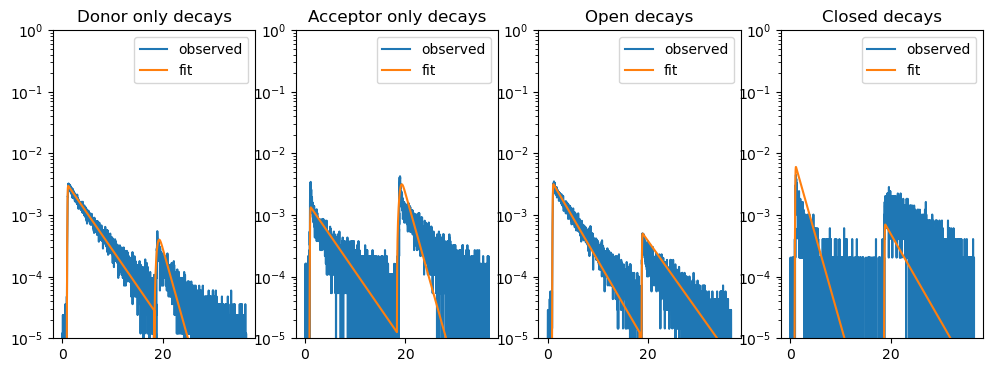

In [39]:
E_donly = decay_donly_DDDA[phrngs_DDDA[1]].sum() / decay_donly_DDDA.sum()
fit_donly_DDDA = np.concatenate([fit_donly_DD/fit_donly_DD.sum()*(1-E_donly), fit_donly_DA/fit_donly_DA.sum()*E_donly])

E_aonly = decay_aonly_DDDA[phrngs_DDDA[1]].sum() / decay_aonly_DDDA.sum()
fit_aonly_DDDA = np.concatenate([fit_donly_DD/fit_donly_DD.sum()*(1-E_aonly), fit_donly_DA/fit_donly_DA.sum()*E_aonly])

E_open = 0.16 # from mpH2MM paper :)
fit_open_DDDA = np.concatenate([fit_open_DD/fit_open_DD.sum()*(1-E_open), fit_open_DA/fit_open_DA.sum()*E_open])

E_closed = 0.67 # from mpH2MM paper :)
fit_closed_DDDA = np.concatenate([fit_closed_DD/fit_closed_DD.sum()*(1-E_closed), fit_closed_DA/fit_closed_DA.sum()*E_donly])

fig, ax = plt.subplots(1,4, figsize=(12,4))

ax[0].semilogy(x_nanotimes_DDA, decay_donly_DDDA/decay_donly_DDDA.sum(), label='observed')
ax[0].semilogy(x_nanotimes_DDA, fit_donly_DDDA/fit_donly_DDDA.sum(), label='fit')
ax[0].set_title("Donor only decays")

ax[1].semilogy(x_nanotimes_DDA, decay_aonly_DDDA/decay_aonly_DDDA.sum(), label='observed')
ax[1].semilogy(x_nanotimes_DDA, fit_aonly_DDDA/fit_aonly_DDDA.sum(), label='fit')
ax[1].set_title("Acceptor only decays")

ax[2].semilogy(x_nanotimes_DDA, decay_open_DDDA/decay_open_DDDA.sum(), label='observed')
ax[2].semilogy(x_nanotimes_DDA, fit_open_DDDA/fit_open_DDDA.sum(), label='fit')
ax[2].set_title("Open decays")

ax[3].semilogy(x_nanotimes_DDA, decay_closed_DDDA/decay_closed_DDDA.sum(), label='observed')
ax[3].semilogy(x_nanotimes_DDA, fit_closed_DDDA/fit_closed_DDDA.sum(), label='fit')
ax[3].set_title("Closed decays")

for a in ax:
    a.legend()
    a.set_ylim([1e-5, 1])

**Compute weights**

Text(0, 0.5, 'weight')

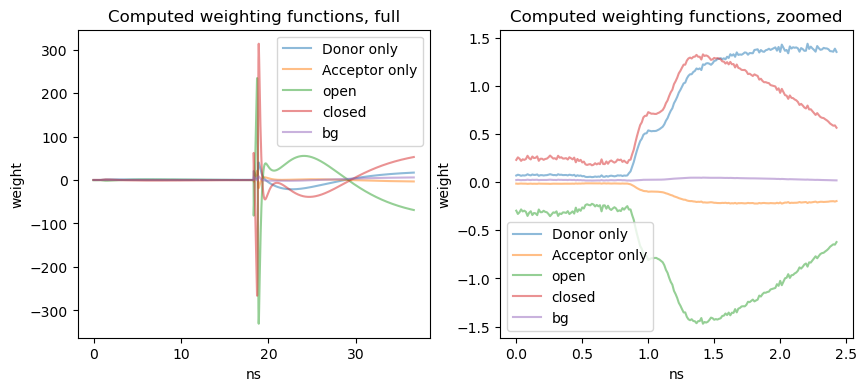

In [40]:
weights_DDDA_fit = compute_weights(nanosDD, fit_donly_DDDA, fit_aonly_DDDA, fit_open_DDDA, fit_closed_DDDA, bg_DDA)

fig, ax = plt.subplots(1,2, figsize=(10,4))
ax[0].plot(x_nanotimes_DDA, weights_DDDA_fit[0,:], label='Donor only', alpha=0.5)
ax[0].plot(x_nanotimes_DDA, weights_DDDA_fit[1,:], label='Acceptor only', alpha=0.5)
ax[0].plot(x_nanotimes_DDA, weights_DDDA_fit[2,:], label='open', alpha=0.5)
ax[0].plot(x_nanotimes_DDA, weights_DDDA_fit[3,:], label='closed', alpha=0.5)
ax[0].plot(x_nanotimes_DDA, weights_DDDA_fit[4,:], label='bg', alpha=0.5)
ax[0].legend()
ax[0].set_title("Computed weighting functions, full")
ax[0].set_xlabel("ns")
ax[0].set_ylabel("weight")

ax[1].plot(x_nanotimes_DDA[:200], weights_DDDA_fit[0,:200], label='Donor only', alpha=0.5)
ax[1].plot(x_nanotimes_DDA[:200], weights_DDDA_fit[1,:200], label='Acceptor only', alpha=0.5)
ax[1].plot(x_nanotimes_DDA[:200], weights_DDDA_fit[2,:200], label='open', alpha=0.5)
ax[1].plot(x_nanotimes_DDA[:200], weights_DDDA_fit[3,:200], label='closed', alpha=0.5)
ax[1].plot(x_nanotimes_DDA[:200], weights_DDDA_fit[4,:200], label='bg', alpha=0.5)

ax[1].legend()
ax[1].set_title("Computed weighting functions, zoomed")
ax[1].set_xlabel("ns")
ax[1].set_ylabel("weight")

**Compute autocorrelation**

Text(0, 0.5, 'G')

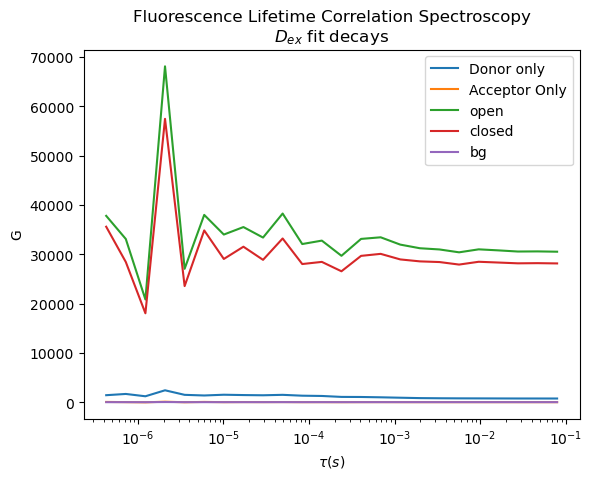

In [41]:
g_DDDA_fit = fcs.correlate(timesDDDA, timesDDDA, bins, weightsT=weights_DDDA_fit, weightsU=weights_DDDA_fit, nanosT=nanosDDDA, nanosU=nanosDDDA)
g_DDDA_fit = fcs.correlate(timesDDDA, timesDDDA, bins, weightsT=weights_DDDA_fit, weightsU=weights_DDDA_fit, 
                           nanosT=nanosDDDA, nanosU=nanosDDDA, normalize=False)

plt.semilogx(tdbins, g_DDDA_fit[0,:], label="Donor only")
plt.semilogx(tdbins, g_DDDA_fit[1,:], label="Acceptor Only")
plt.semilogx(tdbins, g_DDDA_fit[2,:], label="open")
plt.semilogx(tdbins, g_DDDA_fit[3,:], label='closed')
plt.semilogx(tdbins, g_DDDA_fit[4,:], label='bg')

plt.legend()
plt.title("Fluorescence Lifetime Correlation Spectroscopy\n$D_{ex}$ fit decays")
plt.xlabel(r"$\tau (s)$")
plt.ylabel("G")

## 2.4 Cross correlation

In FLCS, I have not seen any examples of cross-correlating different photon streams.
Instead, cross-correlation in FLCS (as far as I have seen) is always performed between weighting functions (aka between species).

Practically, this is done by switching around the order of the species in the `weightsT` and `weightsU` arrays.

So, say we just want to cross-correlate the open and closed conformations, we woudl do the following:

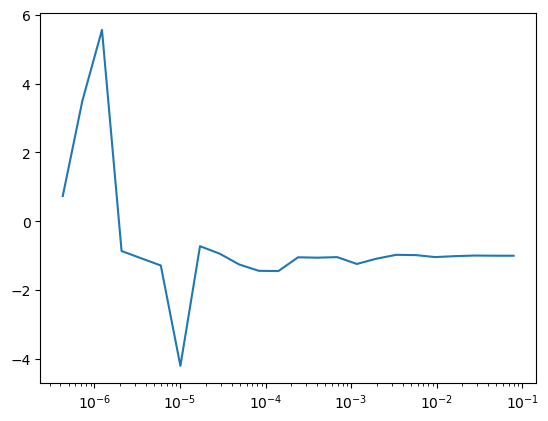

In [42]:
g_DD_cross_oc = fcs.correlate(timesDD, timesDD, bins, weightsT=weights_DD_fit[1,:], weightsU=weights_DD_fit[2,:], nanosT=nanosDD, nanosU=nanosDD)

plt.semilogx(tdbins, -g_DD_cross_oc)

We can perform several cross-correlations at once, by making 2D weights arrays that have the weights functions re-ordered:

below is an example where the open and closed are correlated with their opposite.
So in the first array the order is open-closed, in the second we have closed-open

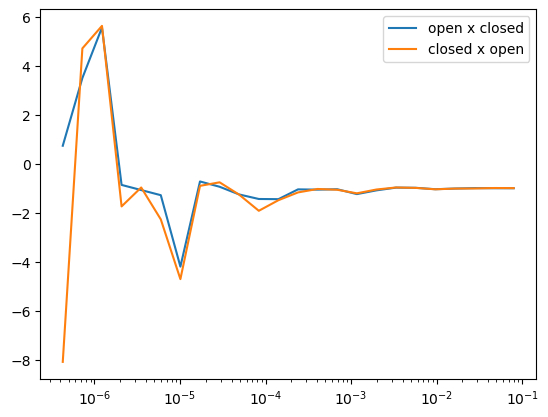

In [43]:
wT_cc = np.vstack([weights_DD_fit[1,:], weights_DD_fit[2,:]])
wU_cc = np.vstack([weights_DD_fit[2,:], weights_DD_fit[1,:]])

g_DD_cross_occo = fcs.correlate(timesDD, timesDD, bins, weightsT=wT_cc, weightsU=wU_cc, nanosT=nanosDD, nanosU=nanosDD)

plt.semilogx(tdbins, -g_DD_cross_occo[0,:], label='open x closed')
plt.semilogx(tdbins, -g_DD_cross_occo[1,:], label='closed x open')

plt.legend()

It is in cross-correlation the the stacked arrays are most often used, so let's do the equivalent calculation below:

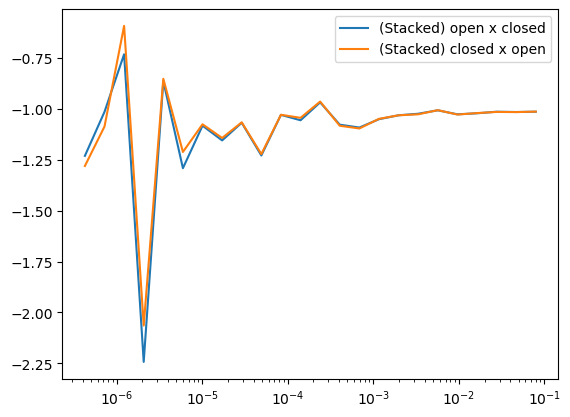

In [44]:
wT_cc_DDDA = np.vstack([weights_DDDA_fit[2,:], weights_DDDA_fit[3,:]])
wU_cc_DDDA = np.vstack([weights_DDDA_fit[3,:], weights_DDDA_fit[2,:]])

g_DD_cross_occo_DDDA = fcs.correlate(timesDDDA, timesDDDA, bins, weightsT=wT_cc_DDDA, weightsU=wU_cc_DDDA, nanosT=nanosDDDA, nanosU=nanosDDDA)

plt.semilogx(tdbins, -g_DD_cross_occo_DDDA[0,:], label='(Stacked) open x closed')
plt.semilogx(tdbins, -g_DD_cross_occo_DDDA[1,:], label='(Stacked) closed x open')

plt.legend()

> **To Eitan and Aviva:**
>
> You will note the my current implementation makes a 1-1 number of weights in T/U
> And the output then has the same number of correlations.
>
> But, I could just as easily do all possible combinations and if weightsT has M weights
> functions, and weightsU has N weights functions, the outupt could then be a 2d array of
> correlations of shape MxN.
>
> In most cases weightsT = weightsU, so then in the square matrix, the diagonal
> would be the auto-correlations, and the off-diagonal will be each cross-correlation
>
> I could also implement an option of whether or not to do the cross-correlation.
>
> Give it some thought, what would be easiest/most clear?
>
> Paul

# 3 Burst-based FCS

If the molecular occupancy of the detection volume is well bellow 1 in the sample, purified FCS becomes a good option for analysis of diffusing species.

In purified FCS however, a burst-search must first be performed to segment the data into chunks of time when a molecule is diffusing throught the confocal spot.

## 3.1 Burst Search

Note that based on the publised paper, the purified FCS generally uses a less strict threshhold compared to traditional burst analysis

Deep copy executed.
 - Performing burst search (verbose=False) ...[DONE]
 - Calculating burst periods ...[DONE]
 - Counting D and A ph and calculating FRET ... 
   - Applying background correction.
   [DONE Counting D/A]
 - - - - - CHANNEL  1 - - - - 
 --> END Fused 14516 bursts (18.6%, 10 iter)

 - Counting D and A ph and calculating FRET ... 
   - Applying background correction.
   [DONE Counting D/A and FRET]
<class 'matplotlib.figure.Figure'>


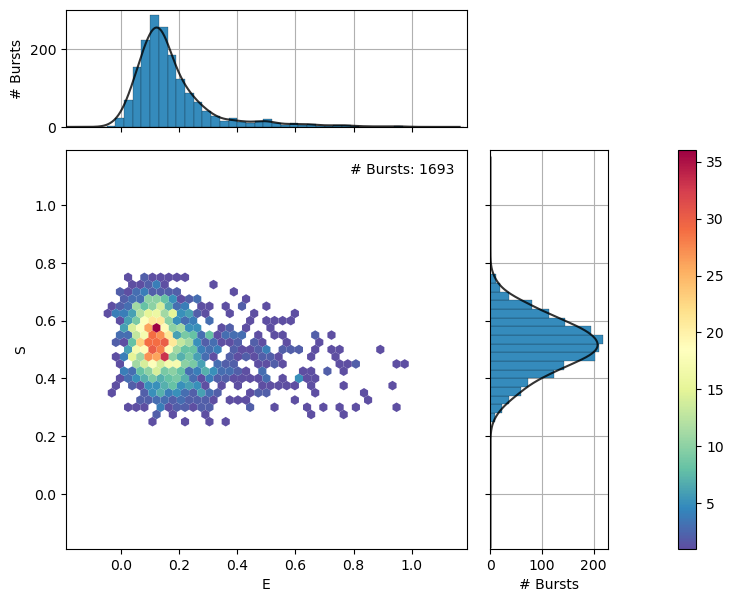

In [45]:
data_raw = data_all.copy()
data_raw.burst_search(m=10, F=6)
data_raw = data_raw.fuse_bursts(ms=0)
data_raw = data_raw.select_bursts(frb.select_bursts.size, th1=30)
data_raw = data_raw.select_bursts(frb.select_bursts.naa, th1=15)
data_raw = data_raw.select_bursts(frb.select_bursts.S, S1=0.25, S2=0.75)

frb.alex_jointplot(data_raw);

## 3.2 Segmenting Data

For purified/burst filtered FCS, the format of `timesT` and `timesU` changes.

The basic principle is that only data that is within 100 ms of a burst should be included, and each of the regions should be treated independently.

Therefore the data is inputed at as a sequence of arrays for both timesT and timesU.

> **Note**
>
> While the arrays within timesT and timesU need not be the same lenght (e.g. cross correlation analysis)
> There must be the same number of arrays in timesT and timesU

So the timesT and timesU will look like:

```python
timesT = [times_chT_burst1, times_chT_burst2, ...]
timesU = [times_chU_burst1, times_chU_burst2, ...]
```
So below is a function that "expands" each burst by 100 ms and returns the array of the selected photon streams:

In [51]:
a = np.array([[1,2],[2,3],[4,5]])
b = np.array([[1,2],[2,3],[4,5]])

np.vstack([a,b])

array([[1, 2],
       [2, 3],
       [4, 5],
       [1, 2],
       [2, 3],
       [4, 5]])

In [52]:
def expand_bursts(data, ph_sel=frb.Ph_sel(Dex='DAem'), expand=0.1):
    """
    Segment data for burst-filtered analysis
    Parameters:
    -----------
    data: frb.Data
        FRETBursts data object to sort into arrays for burst-filtered FCS
    ph_sel: tuple[frb.Ph_sel], optional
        The photon stream(s) to sort into arrays, can be single frb.Ph_sel 
        object, or a sequence thereof. The default is frb.Ph_sel(Dex='DAem')
    expand: float, optional
        Time (in seconds) to expand around bursts. The default is 0.1 (ie 100 ms)
    Returns:
    --------
    times_arrays: list[np.ndarray]
        The photon macrotimes in each burst
    nanos_arrays: list[np.ndarray]
        The photon nanotimes of each burst, organized in a stacked array
        so first TCSPC channel is always 0
    edges: np.ndarray
        The start/end time of each burst, for more optimal
        normalization
    """
    expd = int(expand/data.clk_p)
    shifts, ph_sels, ph_sel_ranges = calculate_shifts(data, ph_sel)
    # first loop: find start/stop times of bursts
    time_arrays, nano_arrays, edges = list(), list(), list()
    for ich in range(data.nch):
        starts = data.mburst[ich].start - expd
        stops = data.mburst[ich].stop + expd
        # perform "fuse" bursts
        cont = True
        while cont:
            # check for overlapping bursts
            mask = starts[1:] > stops[:-1]
            mask_start = np.concatenate([np.array([True,]), mask])
            mask_stop = np.concatenate([mask, np.array([True,])])
            if mask.sum() != mask.size:
                starts = starts[mask_start]
                stops = stops[mask_stop]
            else:
                cont = False
        # get burst times
        edges.append(np.vstack([starts, stops]).T)
        masks = tuple(data.get_ph_mask(ich=ich, ph_sel=sel) for sel in ph_sels)
        full_mask = sum(m for m in masks).astype(np.bool_)
        i = 0
        mn = np.inf
        for start, stop in zip(starts, stops):
            while i < data.ph_times_m[ich].size and data.ph_times_m[ich][i] < start:
                i += 1
            beg = i
            while i < data.ph_times_m[ich].size and data.ph_times_m[ich][i] <= stop:
                i += 1
            end = i
            time_arrays.append(data.ph_times_m[ich][beg:end][full_mask[beg:end]])
            nanos = data.nanotimes[ich][beg:end][full_mask[beg:end]].astype(np.int32)
            for shift, mask in zip(shifts, masks):
                nanos[mask[beg:end][full_mask[beg:end]]] += shift
            nano_arrays.append(nanos.astype(np.uint16))
    return time_arrays, nano_arrays, np.vstack(edges)

**Get the burst arrays, and compute new weights function**

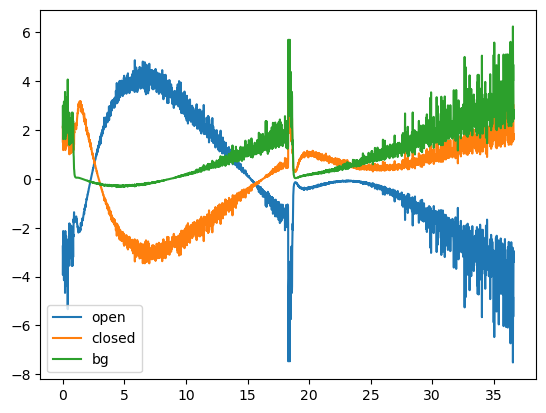

In [53]:
tmbDDDA, nnbDDDA, edDDDA = expand_bursts(data_raw, ph_sel=frb.Ph_sel(Dex='DAem'))

weights_bf_DDDA = compute_weights(nnbDDDA, fit_open_DDDA, fit_closed_DDDA, bg_DDA)

plt.plot(x_nanotimes_DDA, weights_bf_DDDA[0,:], label='open')
plt.plot(x_nanotimes_DDA, weights_bf_DDDA[1,:], label='closed')
plt.plot(x_nanotimes_DDA, weights_bf_DDDA[2,:], label='bg')

plt.legend()

## 3.3 Computing Correlations

Text(0, 0.5, 'G')

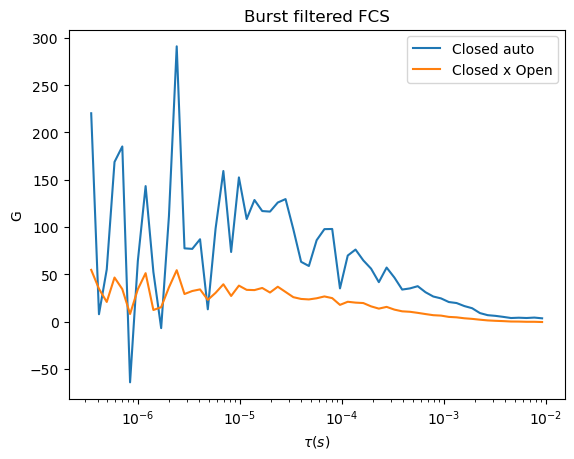

In [55]:
# extend weights arrays
weights_bf_DDDA_T = np.vstack([weights_bf_DDDA[0,:], 
                               weights_bf_DDDA[1,:],
                               weights_bf_DDDA[2,:],
                               weights_bf_DDDA[0,:],
                               weights_bf_DDDA[1,:]])

weights_bf_DDDA_U = np.vstack([weights_bf_DDDA[0,:], 
                               weights_bf_DDDA[1,:],
                               weights_bf_DDDA[2,:],
                               weights_bf_DDDA[1,:],
                               weights_bf_DDDA[0,:]])

# because bursts are much shorter, we need a bins with a smaller range
tbins_bf = np.logspace(-6.5, -2, 60)
bins_bf = (tbins_bf/data_raw.clk_p).astype(np.uint64)
tdbins_bf = tbins_bf[:-1] + np.diff(tbins_bf)/2

g_bf_DDDA = fcs.correlate(tmbDDDA, tmbDDDA, bins_bf, weightsT=weights_bf_DDDA_T, weightsU=weights_bf_DDDA_U, nanosT=nnbDDDA, nanosU=nnbDDDA, edges=edDDDA)


# plt.semilogx(tdbins_bf, )
# plt.semilogx(tdbins_bf, g_bf_DDDA[0,:], label='Open auto')
plt.semilogx(tdbins_bf, g_bf_DDDA[1,:], label='Closed auto')
# plt.semilogx(tdbins_bf, g_bf_DDDA[2,:], label='bg auto')
# plt.semilogx(tdbins_bf, -g_bf_DDDA[3,:], label='Open x Closed')
plt.semilogx(tdbins_bf, -g_bf_DDDA[4,:], label='Closed x Open')
plt.legend()
plt.title("Burst filtered FCS")
plt.xlabel(r"$\tau (s)$")
plt.ylabel("G")

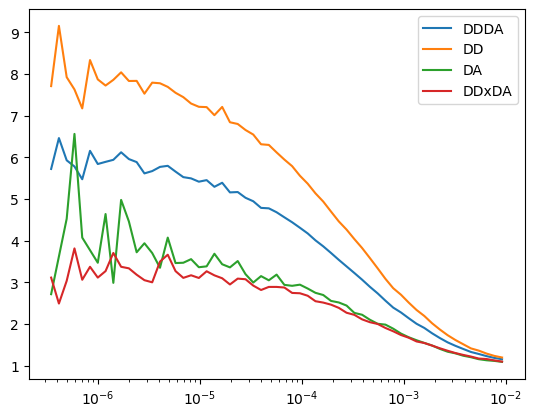

In [57]:
# for no-lifetime
tmbDD, _, edg_raw = expand_bursts(data_raw, ph_sel=frb.Ph_sel(Dex='Dem'))
tmbDA, _, _ = expand_bursts(data_raw, ph_sel=frb.Ph_sel(Dex='Aem'))

g_bfnofilt_DDDA = fcs.correlate(tmbDDDA, tmbDDDA, bins_bf, edges=edDDDA)
g_bfnofilt_DD = fcs.correlate(tmbDD, tmbDD, bins_bf, edges=edg_raw)
g_bfnofilt_DA = fcs.correlate(tmbDA, tmbDA, bins_bf, edges=edg_raw)
g_bfnofilt_DDxDA = fcs.correlate(tmbDD, tmbDA, bins_bf, edges=edg_raw)

plt.semilogx(tdbins_bf, g_bfnofilt_DDDA, label='DDDA')
plt.semilogx(tdbins_bf, g_bfnofilt_DD, label='DD')
plt.semilogx(tdbins_bf, g_bfnofilt_DA, label='DA')
plt.semilogx(tdbins_bf, g_bfnofilt_DDxDA, label='DDxDA')
plt.legend()

**Compute cross-correlation**

# 4. FRET correlation

This section is less developed, as the method is new, I am executing the ideas from [Terterov et. al. 2024](https://doi.org/10.1101/2024.10.31.621265)
Appologies for the lack of explanations.

It is not a part of standard FLCS analysis, and in fact would ideally be executed differently, my use of the weights arrays is more of a hack.

$g_{E}(\tau) = \sum_{all\:photons}{(E_{t}-<E>)(E_{t+\tau}-<E>)}$

In [ ]:
def fret_correlation(data, bins, expand=0.0):
    timesDA, _, _ = expand_bursts(data, ph_sel=frb.Ph_sel(Dex='DAem'), expand=expand)
    timesD, _, _ = expand_bursts(data, ph_sel=frb.Ph_sel(Dex='Dem'), expand=expand)
    timesA, _, _ = expand_bursts(data, ph_sel=frb.Ph_sel(Dex='Aem'), expand=expand)
    Ehat = sum(t.size for t in timesA) / sum(t.size for t in timesDA)
    print(Ehat)
    N = fcs.correlate(timesDA, timesDA, bins, normalize=False, norm_bin_width=False)
    Ndd = fcs.correlate(timesD, timesD, bins, normalize=False, norm_bin_width=False)
    Naa = fcs.correlate(timesA, timesA, bins, normalize=False, norm_bin_width=False)
    Nda = fcs.correlate(timesD, timesA, bins, normalize=False, norm_bin_width=False)
    Nad = fcs.correlate(timesA, timesD, bins, normalize=False, norm_bin_width=False)
    Ecorr = ((((1-(Ehat))**2)*Naa) + ((Ehat**2)*Ndd) - (Ehat*(1-Ehat)*(Nda+Nad)))/N
    return Ecorr, N, Ndd, Naa, Nda, Nad

In [ ]:
calculate_shifts(data_fret, frb.Ph_sel(Dex='DAem'))

In [ ]:
timesF, nanosF = expand_bursts(data_fret, ph_sel=frb.Ph_sel(Dex='DAem'), expand=0.0)
maskAA = [(n > 1498).astype(np.uint16) for n in nanosF]
Emean = np.concatenate(maskAA).sum()/np.concatenate(maskAA).size
print(Emean)
weightT = np.array([[1.0, 1.0], [1.0, 0.0], [0.0, 1.0], [1.0, 0.0], [0.0, 1.0]])
weightU = np.array([[1.0, 1.0], [1.0, 0.0], [0.0, 1.0], [0.0, 1.0], [1.0, 0.0]])

tfretbins = np.arange(0, 1e-3, 1e-6)
fretbins = (tfretbins/data_all.clk_p).astype(np.int64)
tdfretbins = tfretbins[:-1] + np.diff(tfretbins)/2

# calculate the N_taus
graw  = fcs.correlate(timesF, timesF, fretbins, weightsT=weightT, weightsU=weightU, nanosT=maskAA, nanosU=maskAA, 
                     normalize=False, norm_bin_width=False)

# equation 2
gfret = ((((1-Emean)**2)*graw[2,:]) + (((Emean)**2)*graw[1,:]) - (Emean*(1-Emean)*(graw[3:5,:].sum(axis=0))))/graw[0,:]

# alternative method of calculation
Ecorr, N, Ndd, Naa, Nda, Nad = fret_correlation(data_fret, fretbins, expand=0.0)
# plt.plot(tdfretbins[1:], Ecorr[1:])
plt.plot(tdfretbins[1:], gfret[1:])

In [ ]:
plt.semilogx(tdfretbins[1:], graw[0,1:], label='N')
plt.semilogx(tdfretbins[1:], graw[1,1:], label='Ndd')
plt.semilogx(tdfretbins[1:], graw[2,1:], label='Naa')
plt.semilogx(tdfretbins[1:], graw[3,1:], label='Nda')
plt.semilogx(tdfretbins[1:], graw[0,1:], label='Nad')

# 5. Normalization

In calculating the correlation, there are two primary steps

1. Histogramming of delays (caclulating $n(\{(i,j) \ni t_{i}\})$)
2. Normaliztion

Within normalization however, there are two aspects:
1. Division by bin width (the `norm_bin_width` keyword argument)
2. Normalize for edge-effects (the `normalize` keyword argument)

Finally, it should be noted that normalization takes into account the total amount of time observed.
This is traditionally done by takeing the first and last photons of the array to be the beginning and end.
But there is to potential that the measuremnt began before and ended after these times.
While I have never seen this implemented elsewhere, I have incldued the `edges` keword argument, where the 
beginning and end of the measuremtn is specified as a 2 element array `[begin, end]`.
There is also the `minzero` keyword argument, that, if set to `True` will cause the "start" time of the
experiment to be treated as `0` instead of the time of the first photon.
For burst-filtered FCS, this should be specified for each burst.

So the full signature of `fcs.correlate()` is as follows:

```python
fcs.correlate(timesT, timesU, bins, weightsT=None, weightsU=None, nanosT=None, nanosU=None, edges=None, normalize=True, norm_bin_width=True, minzero=False, validate=True, max_cores=4)
```

The `validate` keyword argument is used to indicate whether or not pyFCS should check to make sure that the `timesT/U` arrays are monotinically increasing.
If the inputs are not monotonically increasing the results of the algorithm are undefined, but the check does take additional time, so if you don't mind
not getting an error if there is an out-of-order photon, or you are sure there are none, you can for make the function call a tiny bit faster by specifying `validate=False`.

`max_cores` is also an optimizing parameter, and is not related to how the values are calculated. For burst-filtered FCS, the caclulation is parallelizable, as each burst can be computed separately and the results summed. `max_cores` is simply the number of parallel threads to use. This is therefore a speed-optimizing parameter, where you might be able to reduce the calculation time by a few percent by finding the optimal number of cores to use based on your processor.

## 5.1 `fcs.normalize` and `fcs.normalization_factor` Functions

These functions are used in the normalization side of the calcualtion of correlations.

> **Note**
>
> These functions should only be used when you want to examine **both** non-normalized and normalized arrays.
> Otherwise, if it is only the normalized correlation you are interested in, then `fcs.correlate()` with all
> normalization keyword arguments set to `True` (the default) will be faster.

`fcs.normalization_factor` takes the same input as `fcs.correlate`, e.g. 
```python
norm_factor = fcs.normalization_factor(timesT, timesU, bins, edges=None, normalize=True, norm_bin_width=True, minzero=False, validate=True)
```
with the exclusion of the `weightsT/U` and `nanosT/U` arguments, as they have not impact on the normalization factor.

The output of `fcs.normalization_factor` can then be *multiplied* by the output of `fcs.correlate()` (with the oposite `normalize` and `norm_bin_width` values)
to get the properly normalized array:

In [ ]:
corrl_norm = fcs.correlate(timesDD, timesDD, bins, normalize=True, norm_bin_width=True)
corrl_notnorm = fcs.correlate(timesDD, timesDD, bins, normalize=False, norm_bin_width=False)
norm = fcs.normalization_factor(timesDD, timesDD, bins, normalize=True, norm_bin_width=True)

np.allclose(corrl_norm, norm*corrl_notnorm)

`fcs.normalize()` adds the G parameter, which is the correlation from `fcs.correlate()` at the beginning, and performs the multiplication:

```python
fcs.normalize(G, timesT, timesU, bins, edges=None, normalize=True, norm_bin_width=True, minzero=False, validate=True)
```

meaning that taking the output of `fcs.correlate()` and feeding it into `fcs.normalize()` is the same as multiplyng it by the output of `fcs.normalization_factor()`

Again, unless you really want both the non-normalized and normalized resutls, it is always faster to just use `fcs.correlate()`.

In [ ]:
np.allclose(fcs.normalize(corrl_notnorm, timesDD, timesDD, bins, normalize=True, norm_bin_width=True), norm*corrl_notnorm)

# 6 Appendices

It is also posible to specify weights per photon, instead of by index.
So that basic input becomes:

```python
corrl = fcs.correlate(timesT, timesU, bins, weigthsT=weightsT, weightsU=weightsU)
```

and instead of `weigthsT/U` being defined by the number of nanotime indexes, they are the same "shape" as `timesT/U`.
Similar to when using nanotime indexes, multiple weight functions can be calculated together, and similar to when using the nanotime index, the array should be organized `[decay, time]`.

For example if there are 4 decays and `timesT` has shape `(50, )`, `weightsT` should have shape `(4, 50)`.

This is also possible for burst-filtered fcs, in which case `weightsT` become a sequence of the same length as `timesT`, and each array within has the same cooresponding patern in it's shape, ie if the shapes of `timesT` are `[(33,), (58,), (45)]`, then `weightsT` would be `[(4, 33), (4, 58), (4, 45)]`.

In [ ]:
wT = [weights_bf_DDDA[:,nD] for nD in nnbDDDA]